In [29]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

plt.style.use("../style/style-formal.mplstyle")

In [30]:
def calc_afl_perf_from_json(results, reproduced_bugs=None, ks=[1, 2, 3, 4, 5]):
    bug2min_afl_rank = dict()
    for bug_name in results["buggy_methods"]:
        if len(results["buggy_methods"][bug_name]) == 0:
            continue
        if reproduced_bugs is not None and bug_name not in reproduced_bugs:
            continue
        min_afl_rank = min(
            [
                v["autofl_rank"]
                for method_name, v in results["buggy_methods"][bug_name].items()
            ]
        )
        bug2min_afl_rank[bug_name] = min_afl_rank

    afl_perf = [
        len([v for bug_name, v in bug2min_afl_rank.items() if (v <= k)]) for k in ks
    ]
    return afl_perf

def visualize_performance(exp_list, score_data, repetition, fig_title, legend_loc, legend_ncol=1):
    plt.figure(figsize=(7, 5))
    for exp in exp_list:
        score = calc_afl_perf_from_json(score_data[exp['name']])
        plt.plot(
            range(1, 6),
            score,
            "x-",
            label=f"{exp.get('label') or exp.get('name')}",
        )

    if legend_loc == "center right":
        plt.legend(loc="lower right", bbox_to_anchor=(1.0, 0.1), ncol=legend_ncol, fontsize=12, frameon=True)
    else:
        plt.legend(loc=legend_loc, ncol=legend_ncol, fontsize=12, frameon=True)
    
    # plt.legend(loc="lower center", bbox_to_anchor=(1.0, 0.1), ncol=legend_ncol, fontsize=12, frameon=True)

    plt.xlabel("k", fontsize=14)
    plt.ylabel("acc@k", fontsize=14)
    plt.xticks(range(1, 6), fontsize=12)
    plt.yticks(fontsize=12)
    plt.title(fig_title, fontsize=16)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()

In [31]:
def calc_mrr(data):
    """
    Calculate MRR (Mean Reciprocal Rank)
    """
    total_rr = 0.0
    bug_cnt = 0

    for bug_name, method_info in data:
        if not method_info:
            continue
        
        # Collect ranks for all suspicious elements of this bug
        ranks = [
            info.get("autofl_rank")
            for info in method_info.values()
            if isinstance(info, dict) and info.get("autofl_rank") is not None
        ]

        if not ranks:
            continue

        best_rank = min(ranks)

        # reciprocal rank
        rr = 1.0 / best_rank

        total_rr += rr
        bug_cnt += 1

    if bug_cnt == 0:
        return 0.0

    return total_rr / bug_cnt

In [32]:
def calc_acc_at_n(data, n_rank=1):
    """
    Calculate Acc@N (Accuracy at N)
    Returns success bug count / total bug count
    """
    total_bug_cnt = 0
    success_cnt = 0

    for bug_name, method_info in data:
        if not method_info:
            continue

        total_bug_cnt += 1
        
        ranks = [
            info.get("autofl_rank")
            for info in method_info.values()
            if isinstance(info, dict) and info.get("autofl_rank") is not None
        ]
        
        if ranks:
            best_rank = min(ranks)
        else:
            continue
            
        if best_rank <= n_rank:
            success_cnt += 1

    if total_bug_cnt == 0:
        return 0.0, 0
    else:
        return round(success_cnt / total_bug_cnt, 3), success_cnt

In [33]:
def calc_ap(data):
    """
    Calculate Average Precision (AP)
    """
    result = {}

    for bug_name, method_info in data:
        if not method_info:
            continue
        
        result[bug_name] = []

        # Collect ranks for all suspicious elements of this bug
        ranks = [
            info.get("autofl_rank")
            for info in method_info.values()
            if isinstance(info, dict) and info.get("autofl_rank") is not None
        ]
        ranks.sort()
        for index, autofl_rank in enumerate(ranks):
            if autofl_rank is not None:
                val = (index + 1) / autofl_rank
                result[bug_name].append(val)

    total = 0
    cnt = 0
    for bug_name in result:
        ap_list = result[bug_name]
        total += sum(ap_list)
        cnt += len(ap_list)

    return total / cnt

In [34]:
def calc_map(data):
    """
    Compute Mean Average Precision (MAP)
    """
    ap_values = []

    for bug_name, method_info in data:
        if not method_info:
            continue

        # Collect absolute ranks of faulty methods
        ranks = [
            info.get("autofl_rank")
            for info in method_info.values()
            if isinstance(info, dict) and info.get("autofl_rank") is not None
        ]
        ranks.sort()

        # AP computation
        ap_sum = 0.0
        for idx, autofl_rank in enumerate(ranks, start=1):
            if autofl_rank is not None:
                ap_sum += (idx / autofl_rank)

        ap_i = ap_sum / len(ranks)
        ap_values.append(ap_i)

    if not ap_values:
        return 0.0

    return round(sum(ap_values) / len(ap_values), 6)

In [35]:
def make_result(label, project, data):
    map = round(calc_map(data), 3)
    acc_1_ratio, acc_1_value = calc_acc_at_n(data, 1)
    acc_2_ratio, acc_2_value = calc_acc_at_n(data, 2)
    acc_3_ratio, acc_3_value = calc_acc_at_n(data, 3)
    acc_4_ratio, acc_4_value = calc_acc_at_n(data, 4)
    acc_5_ratio, acc_5_value = calc_acc_at_n(data, 5)
    mrr = round(calc_mrr(data), 3)

    return {
        "label": label,
        "project": project,
        "Acc@1": acc_1_value,
        "Acc@2": acc_2_value,
        "Acc@3": acc_3_value,
        "Acc@4": acc_4_value,
        "Acc@5": acc_5_value,
        "Mean Reciprocal Rank (MRR)": mrr,
        "Mean Average Precision (MAP)": map,
    }


def main(exp_list, repetition=1, fig_title="Performance for GPT 4.1", legend_loc="lower right", legend_ncol=1):
    results = []
    score_data = {}
    for exp in exp_list:
        score_path_json = f"../combined_fl_results/{exp['name']}/{exp['gpt_version']}_R{repetition}_full_light.json"
        with open(score_path_json, "r") as f:
            raw_data = json.load(f)
        score_data[exp['name']] = raw_data
        data = raw_data.get("buggy_methods", {}).items()

        grouped_data = defaultdict(dict)

        for bug_name, value in data:
            dataset = bug_name.split("_")[0].lower()
            grouped_data[dataset][bug_name] = value

        grouped_data = dict(grouped_data)

        # Result for entire project
        results.append(
            make_result(
                label=f"{exp['label']}",
                project="ALL",
                data=data,
            )
        )

        # Result per project
        for dataset in sorted(grouped_data.keys()):
            results.append(
                make_result(
                    label=f"{exp['label']}",
                    project=dataset.upper(),
                    data=grouped_data[dataset].items(),
                )
            )

        
    visualize_performance(exp_list=exp_list, score_data=score_data, repetition=repetition, fig_title=fig_title, legend_loc=legend_loc, legend_ncol=legend_ncol)

    summary = pd.DataFrame([res for res in results ])
    column_order = ["label", "project", "Acc@1", "Acc@2", "Acc@3", "Acc@4", "Acc@5", "Mean Reciprocal Rank (MRR)", "Mean Average Precision (MAP)"]
    summary = summary.reindex(columns=column_order)
    display(summary)
    print()

    return summary


In [36]:
LABEL_MAP = {
    "AutoFL": r"\autofl",
    "AutoFL_onlyFT": r"\autoflonlyft",

    "IRHistory_CR": r"\irflcr",
    "IRHistory_30days": r"\irfldays{30}",
    "IRHistory_60days": r"\irfldays{60}",
    "IRHistory_90days": r"\irfldays{90}",

    "ReportFL_CR": r"\namecr",
    "ReportFL_30days": r"\namedays{30}",
    "ReportFL_60days": r"\namedays{60}",
    "ReportFL_90days": r"\namedays{90}",

    "ReportFL_Random": r"\namerandom",
}

LABEL_ORDER = [
    "AutoFL",
    "AutoFL_onlyFT",
    "ReportFL_CR",
    "ReportFL_30days",
    "ReportFL_60days",
    "ReportFL_90days",
    "ReportFL_Random",
]

PROJECT_MAP = {
    "CLI": "Cli",
    "CODEC": "Codec",
    "COLLECTIONS": "Collections",
    "COMPRESS": "Compress",
    "CSV": "Csv",
    "JXPATH": "JXPath",
    "LANG": "Lang",
    "MATH": "Math",
    "ALL": "Overall",
}

PROJECT_ORDER = [
    "CLI",
    "CODEC",
    "COLLECTIONS",
    "COMPRESS",
    "CSV",
    "JXPATH",
    "LANG",
    "MATH",
    "ALL",
]

def latex_label(label):
    return LABEL_MAP.get(label, label)

def print_latex_table(summary_r1, summary_r5):
    metrics = ["Acc@1", "Acc@2", "Acc@3", "Acc@4", "Acc@5", "Mean Reciprocal Rank (MRR)", "Mean Average Precision (MAP)"]
    is_float = [False, False, False, False, False, True, True]

    merged = pd.merge(summary_r1, summary_r5, on=["label", "project"], suffixes=("_r1", "_r5"))
    merged = merged[~merged["label"].str.startswith("IRHistory")].copy()
    merged["label"] = pd.Categorical(merged["label"], categories=LABEL_ORDER, ordered=True)
    merged["project"] = pd.Categorical(merged["project"], categories=PROJECT_ORDER, ordered=True)
    merged = merged.sort_values(["label", "project"])

    project_max_r1 = {}
    project_max_r5 = {}

    for project in PROJECT_ORDER:
        df = merged[merged["project"] == project]

        if len(df) == 0:
            continue

        project_max_r1[project] = {
            metric: df[f"{metric}_r1"].max()
            for metric in metrics
        }

        project_max_r5[project] = {
            metric: df[f"{metric}_r5"].max()
            for metric in metrics
        }

    def fmt(val, is_bold, is_float_metric):
        s = f"{val:.3f}" if is_float_metric else str(int(val))
        return f"\\textbf{{{s}}}" if is_bold else s
    
    prev_label = None

    for _, row in merged.iterrows():
        if prev_label is not None and prev_label != row["label"]:
            print(r"\cmidrule(lr){2-17}")

        prev_label = row["label"]

        approach = (
            latex_label(row["label"])
            if row["project"] == PROJECT_ORDER[0]
            else ""
        )

        r1 = [
            fmt(
                row[f"{m}_r1"],
                row[f"{m}_r1"] == project_max_r1[row["project"]][m],
                is_float[j]
            )
            for j, m in enumerate(metrics)
        ]

        r5 = [
            fmt(
                row[f"{m}_r5"],
                row[f"{m}_r5"] == project_max_r5[row["project"]][m],
                is_float[j]
            )
            for j, m in enumerate(metrics)
        ]
        vals = " & ".join(r1 + r5)

        if row["project"] == "ALL":
            print(r"\cmidrule(lr){3-17}")

        print(
            f"& "
            f"{approach if row['project'] != PROJECT_ORDER[0] else rf'\multirow{{{len(PROJECT_ORDER)}}}{{*}}{{{approach}}}'} "
            f"& {PROJECT_MAP[row['project']]} "
            f"& {vals} \\\\"
        )
        
        if row["project"] == "ALL":
            print(r"\cmidrule(lr){3-17}")

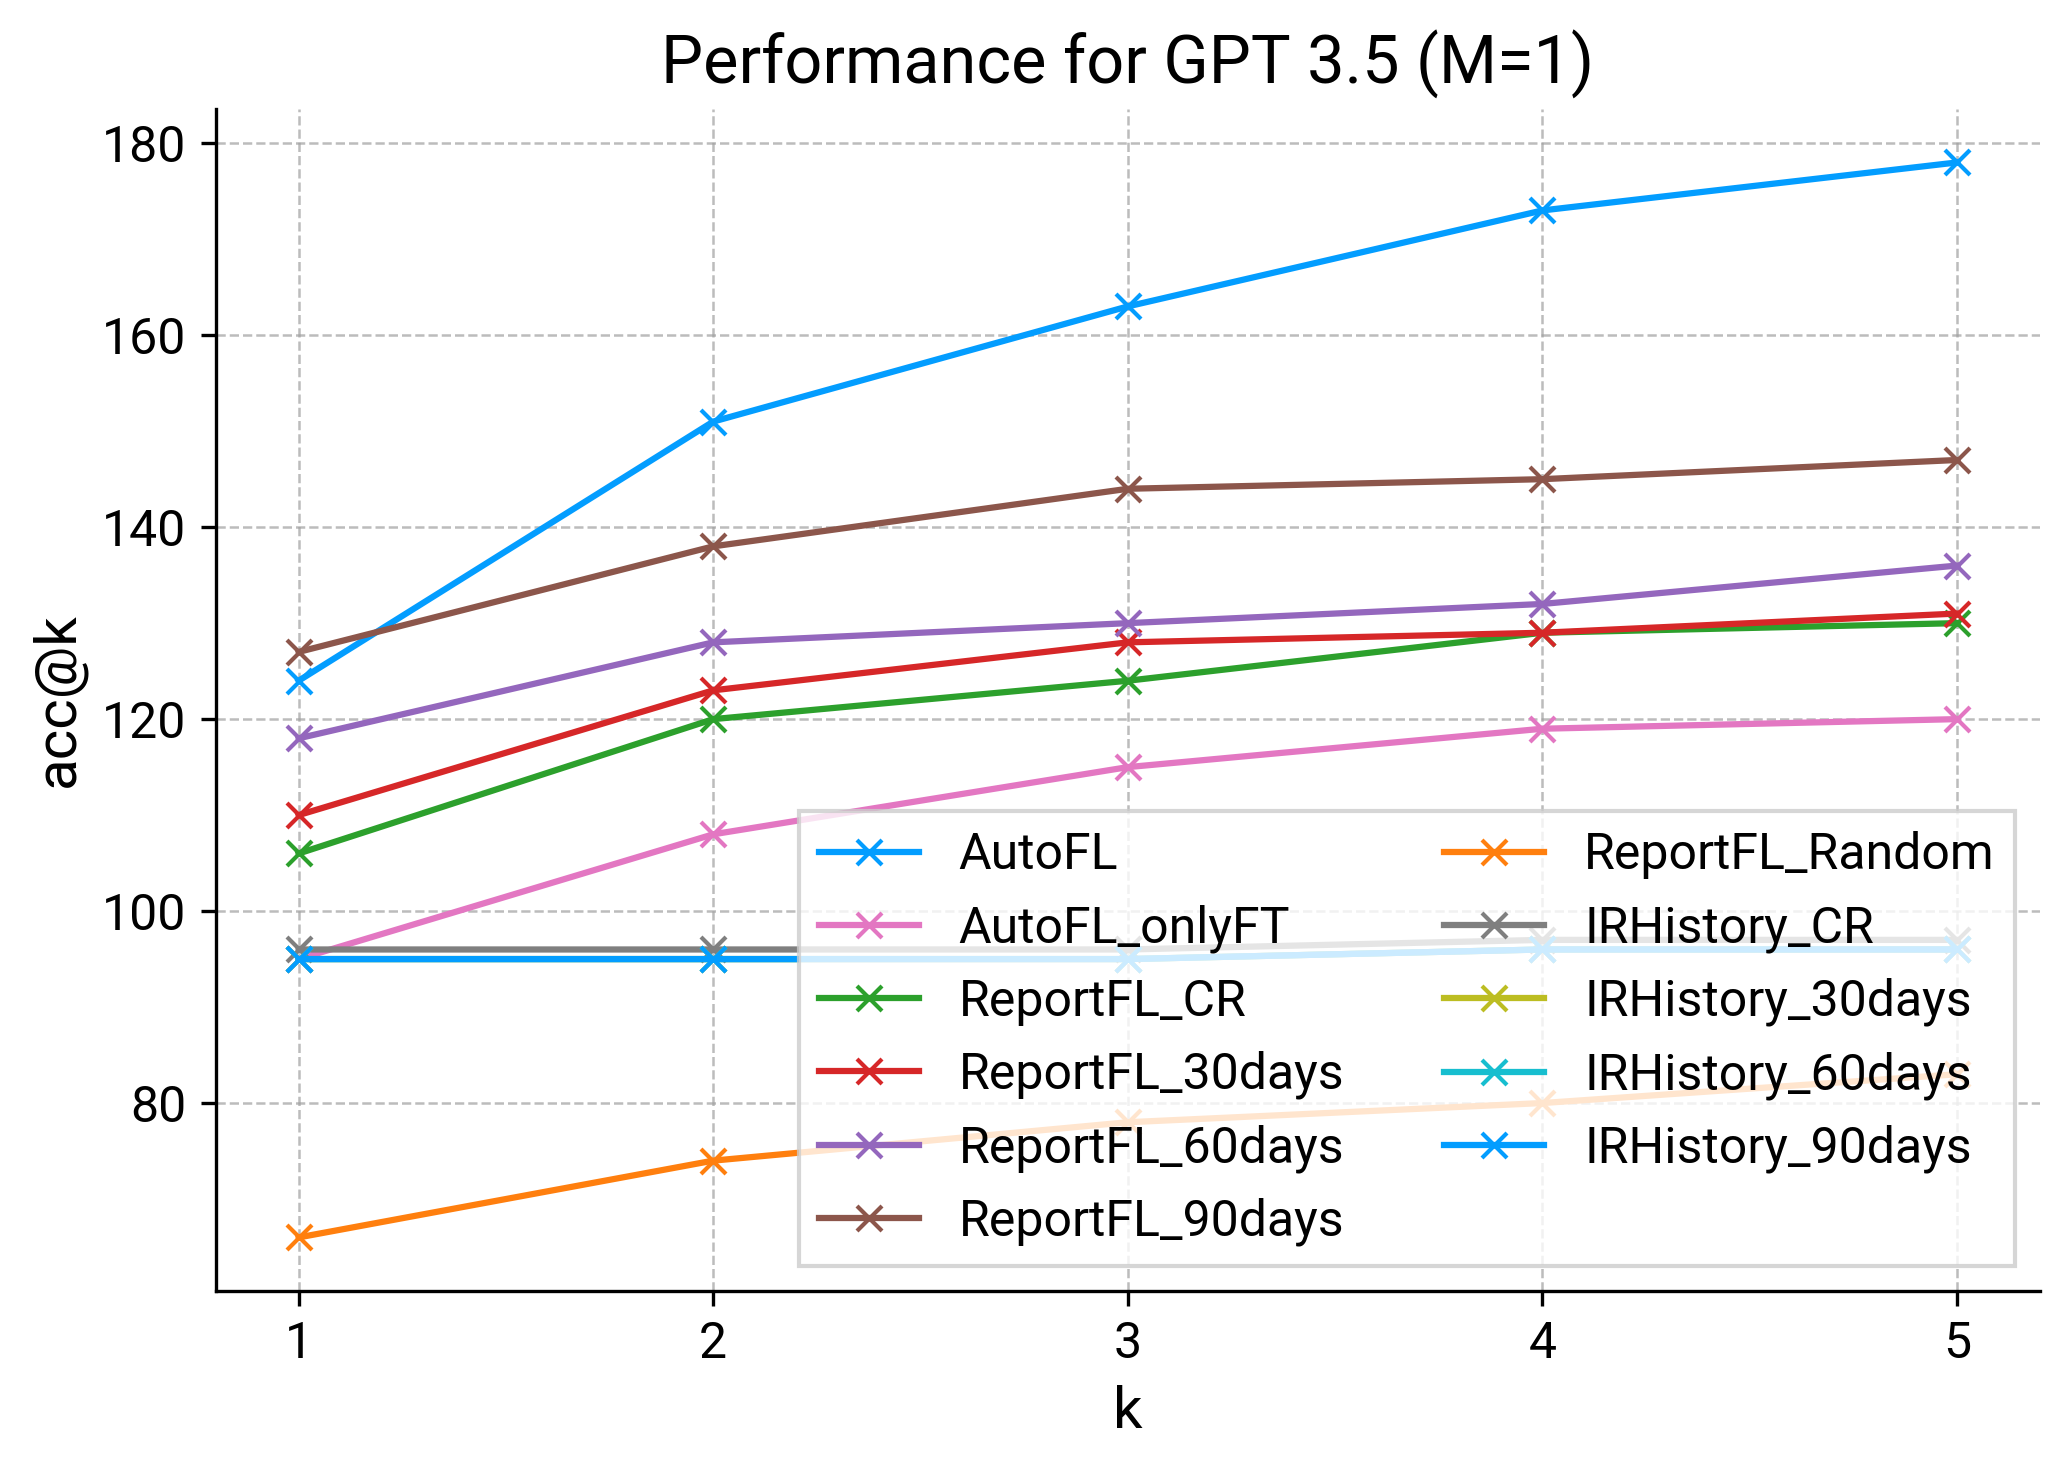

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,124,151,163,173,178,0.521,0.493
1,AutoFL,CLI,10,11,11,12,13,0.388,0.373
2,AutoFL,CODEC,7,8,9,11,11,0.550,0.543
3,AutoFL,COLLECTIONS,0,1,1,1,1,0.500,0.500
4,AutoFL,COMPRESS,17,22,23,25,25,0.477,0.463
...,...,...,...,...,...,...,...,...,...
94,IRHistory_90days,COMPRESS,17,17,17,17,17,0.381,0.335
95,IRHistory_90days,CSV,5,5,5,6,6,0.383,0.342
96,IRHistory_90days,JXPATH,2,2,2,2,2,0.092,0.048
97,IRHistory_90days,LANG,35,35,35,35,35,0.594,0.495


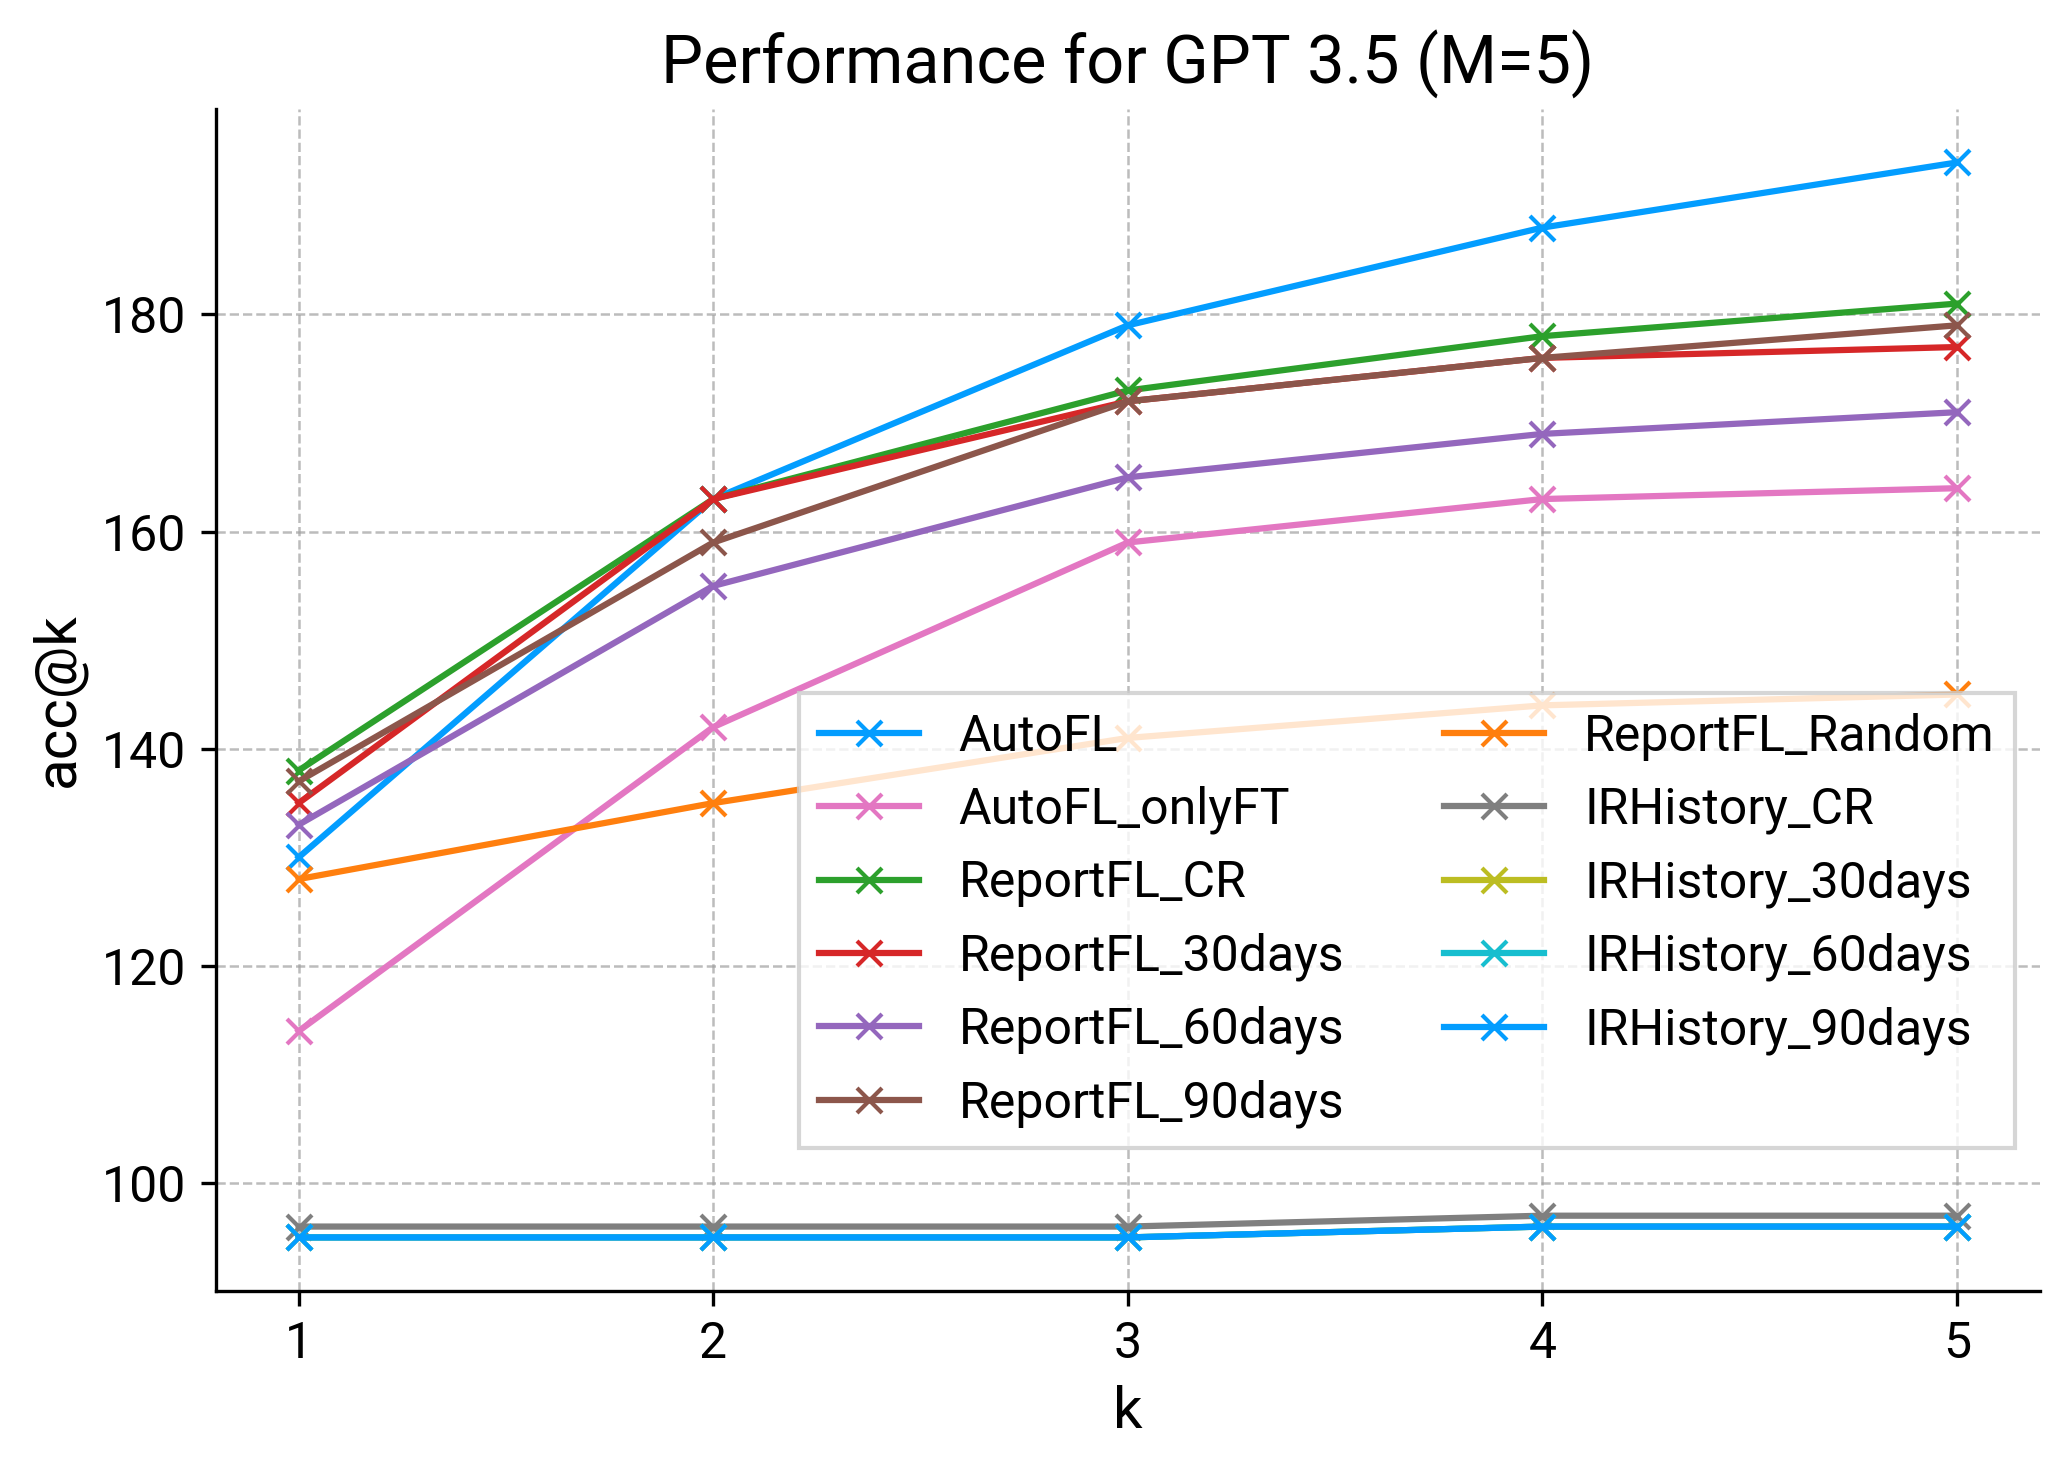

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,130,163,179,188,194,0.553,0.535
1,AutoFL,CLI,13,14,14,15,15,0.478,0.438
2,AutoFL,CODEC,6,9,9,11,12,0.534,0.526
3,AutoFL,COLLECTIONS,0,0,0,0,1,0.200,0.200
4,AutoFL,COMPRESS,22,26,28,29,30,0.576,0.559
...,...,...,...,...,...,...,...,...,...
94,IRHistory_90days,COMPRESS,17,17,17,17,17,0.381,0.335
95,IRHistory_90days,CSV,5,5,5,6,6,0.383,0.342
96,IRHistory_90days,JXPATH,2,2,2,2,2,0.092,0.048
97,IRHistory_90days,LANG,35,35,35,35,35,0.594,0.495



& \multirow{9}{*}{\autofl} & Cli & \textbf{10} & \textbf{11} & \textbf{11} & \textbf{12} & \textbf{13} & \textbf{0.388} & \textbf{0.373} & \textbf{13} & \textbf{14} & 14 & 15 & 15 & \textbf{0.478} & \textbf{0.438} \\
&  & Codec & 7 & 8 & \textbf{9} & \textbf{11} & \textbf{11} & \textbf{0.550} & \textbf{0.543} & 6 & 9 & 9 & 11 & 12 & 0.534 & 0.526 \\
&  & Collections & 0 & 1 & 1 & 1 & 1 & 0.500 & 0.500 & 0 & 0 & 0 & 0 & 1 & 0.200 & 0.200 \\
&  & Compress & 17 & \textbf{22} & \textbf{23} & \textbf{25} & \textbf{25} & \textbf{0.477} & \textbf{0.463} & \textbf{22} & \textbf{26} & \textbf{28} & \textbf{29} & \textbf{30} & \textbf{0.576} & \textbf{0.559} \\
&  & Csv & \textbf{8} & \textbf{8} & \textbf{8} & 8 & 8 & \textbf{0.590} & \textbf{0.544} & \textbf{6} & 7 & 7 & 8 & 8 & 0.500 & \textbf{0.481} \\
&  & JXPath & 0 & 0 & 0 & 0 & 1 & 0.019 & 0.021 & 1 & 1 & 2 & \textbf{3} & \textbf{4} & 0.089 & 0.061 \\
&  & Lang & 36 & \textbf{44} & \textbf{48} & \textbf{49} & \textbf{50} & \textbf{0.723}

In [37]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_CR",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_90days",
    },
    {
        "name": "reportfl_random",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_Random",
    },
    {
        "name": "irfl_current",
        "gpt_version": "",
        "label": "IRHistory_CR",
    },
    {
        "name": "irfl",
        "gpt_version": "",
        "label": "IRHistory_30days",
    },
    {
        "name": "irfl_60days",
        "gpt_version": "",
        "label": "IRHistory_60days",
    },
    {
        "name": "irfl_90days",
        "gpt_version": "",
        "label": "IRHistory_90days",
    }
]

res_1 = main(exp_list=EXP_LIST, repetition=1, fig_title="Performance for GPT 3.5 (M=1)", legend_loc="lower right", legend_ncol=2)
res_2 = main(exp_list=EXP_LIST, repetition=5, fig_title="Performance for GPT 3.5 (M=5)", legend_loc="center right", legend_ncol=2)
print_latex_table(res_1, res_2)

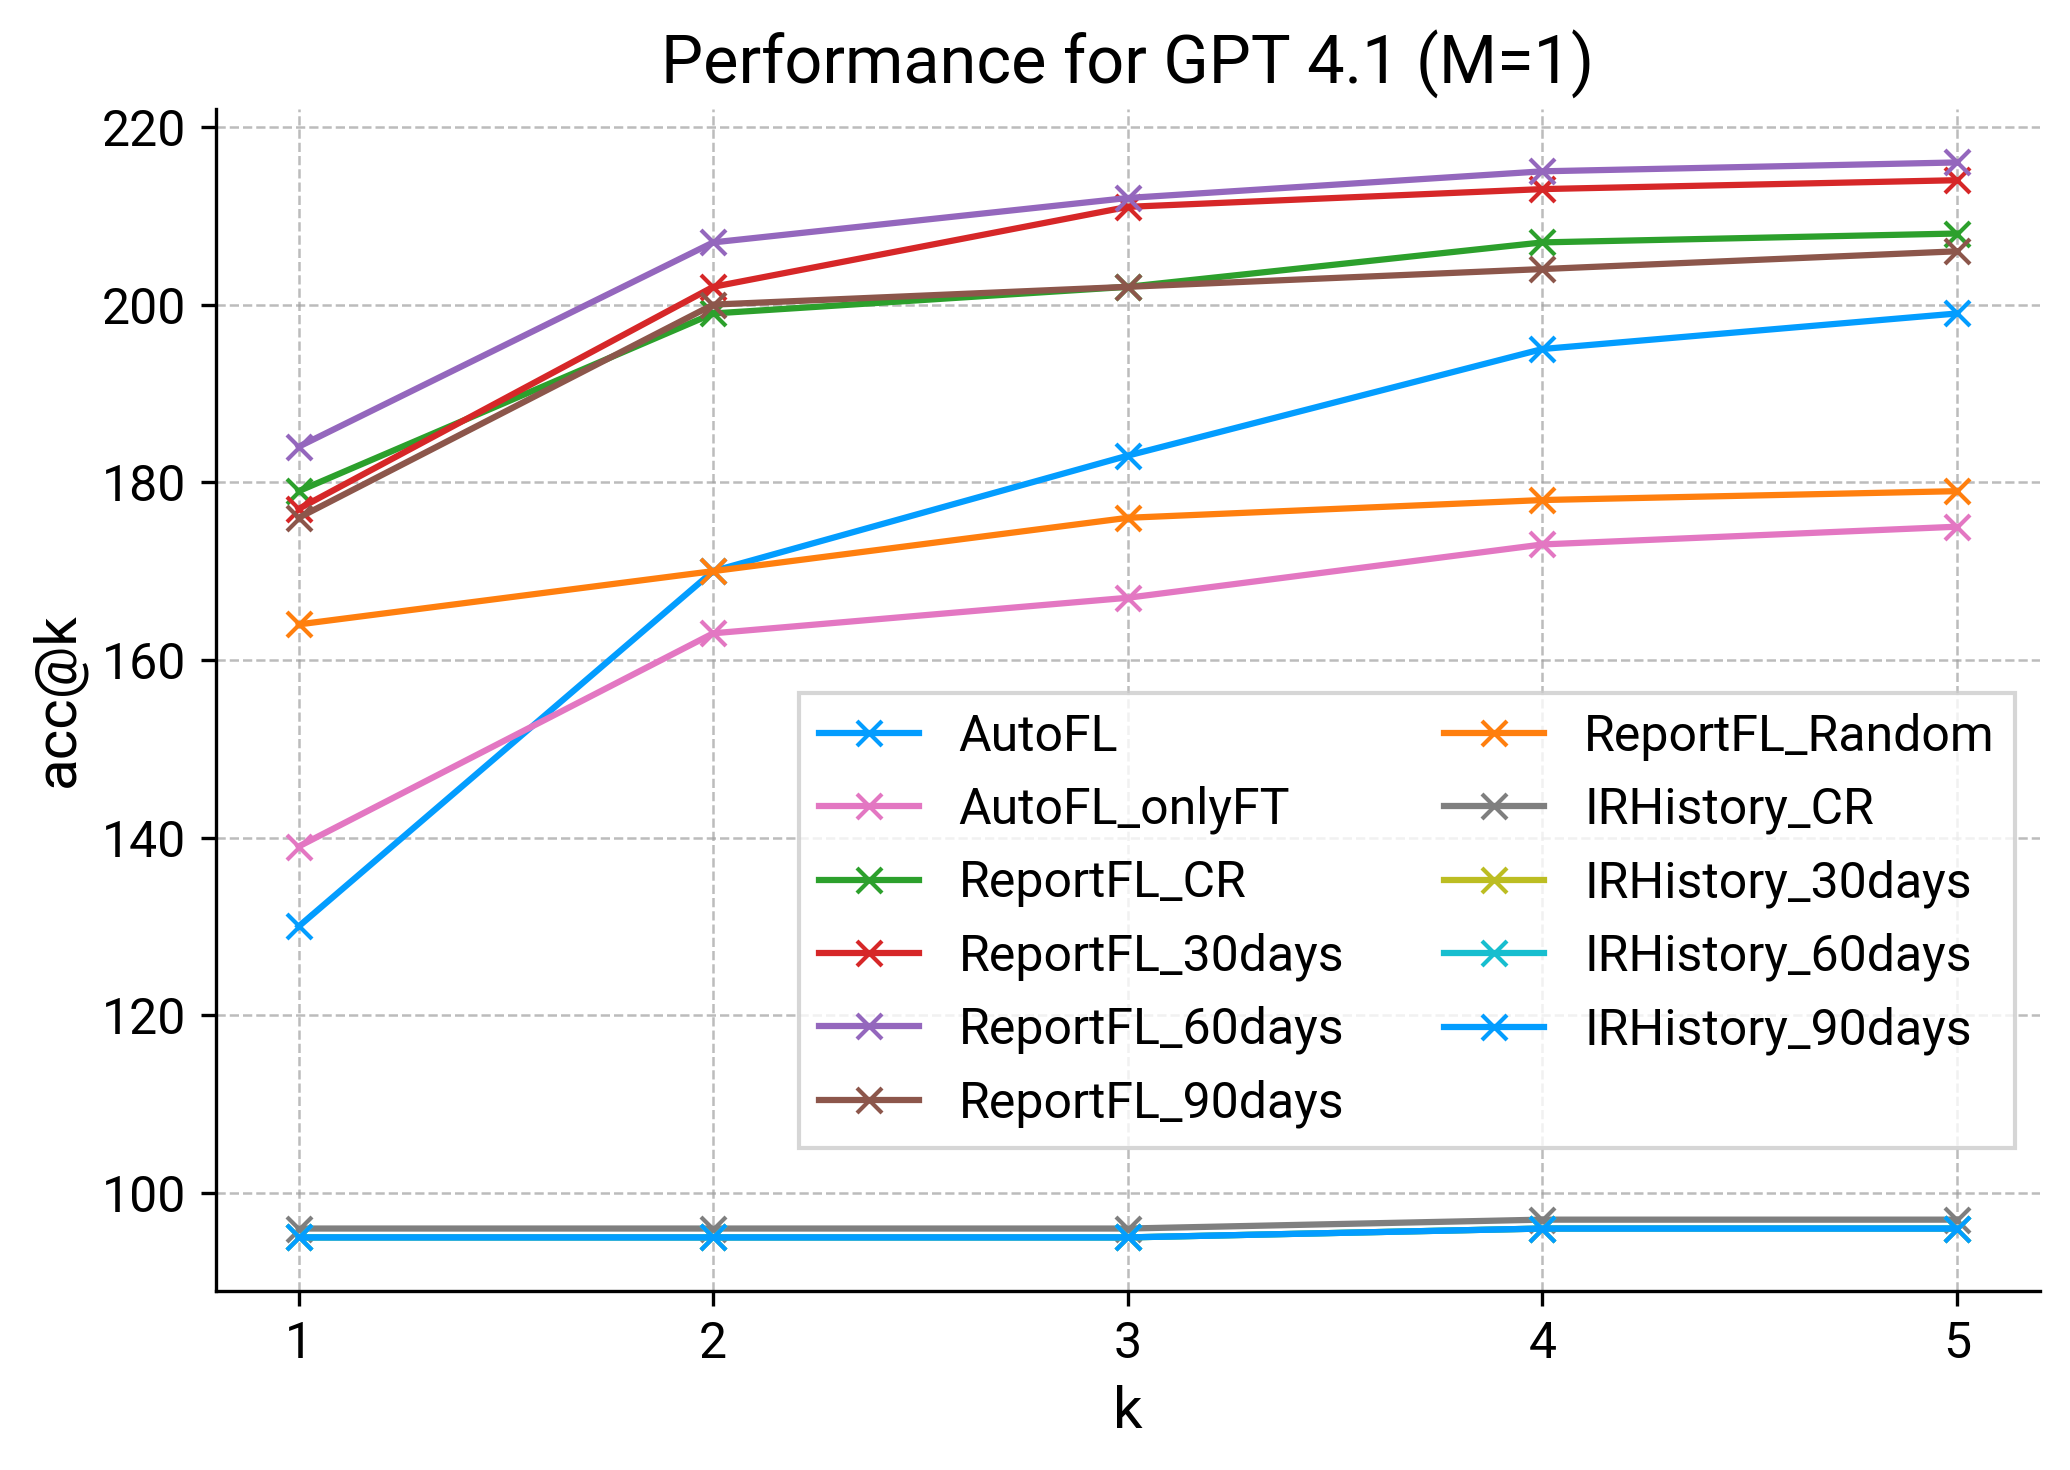

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,130,170,183,195,199,0.561,0.535
1,AutoFL,CLI,9,14,15,19,19,0.440,0.433
2,AutoFL,CODEC,6,11,12,13,13,0.587,0.555
3,AutoFL,COLLECTIONS,1,1,1,1,1,1.000,1.000
4,AutoFL,COMPRESS,19,23,24,27,28,0.515,0.502
...,...,...,...,...,...,...,...,...,...
94,IRHistory_90days,COMPRESS,17,17,17,17,17,0.381,0.335
95,IRHistory_90days,CSV,5,5,5,6,6,0.383,0.342
96,IRHistory_90days,JXPATH,2,2,2,2,2,0.092,0.048
97,IRHistory_90days,LANG,35,35,35,35,35,0.594,0.495


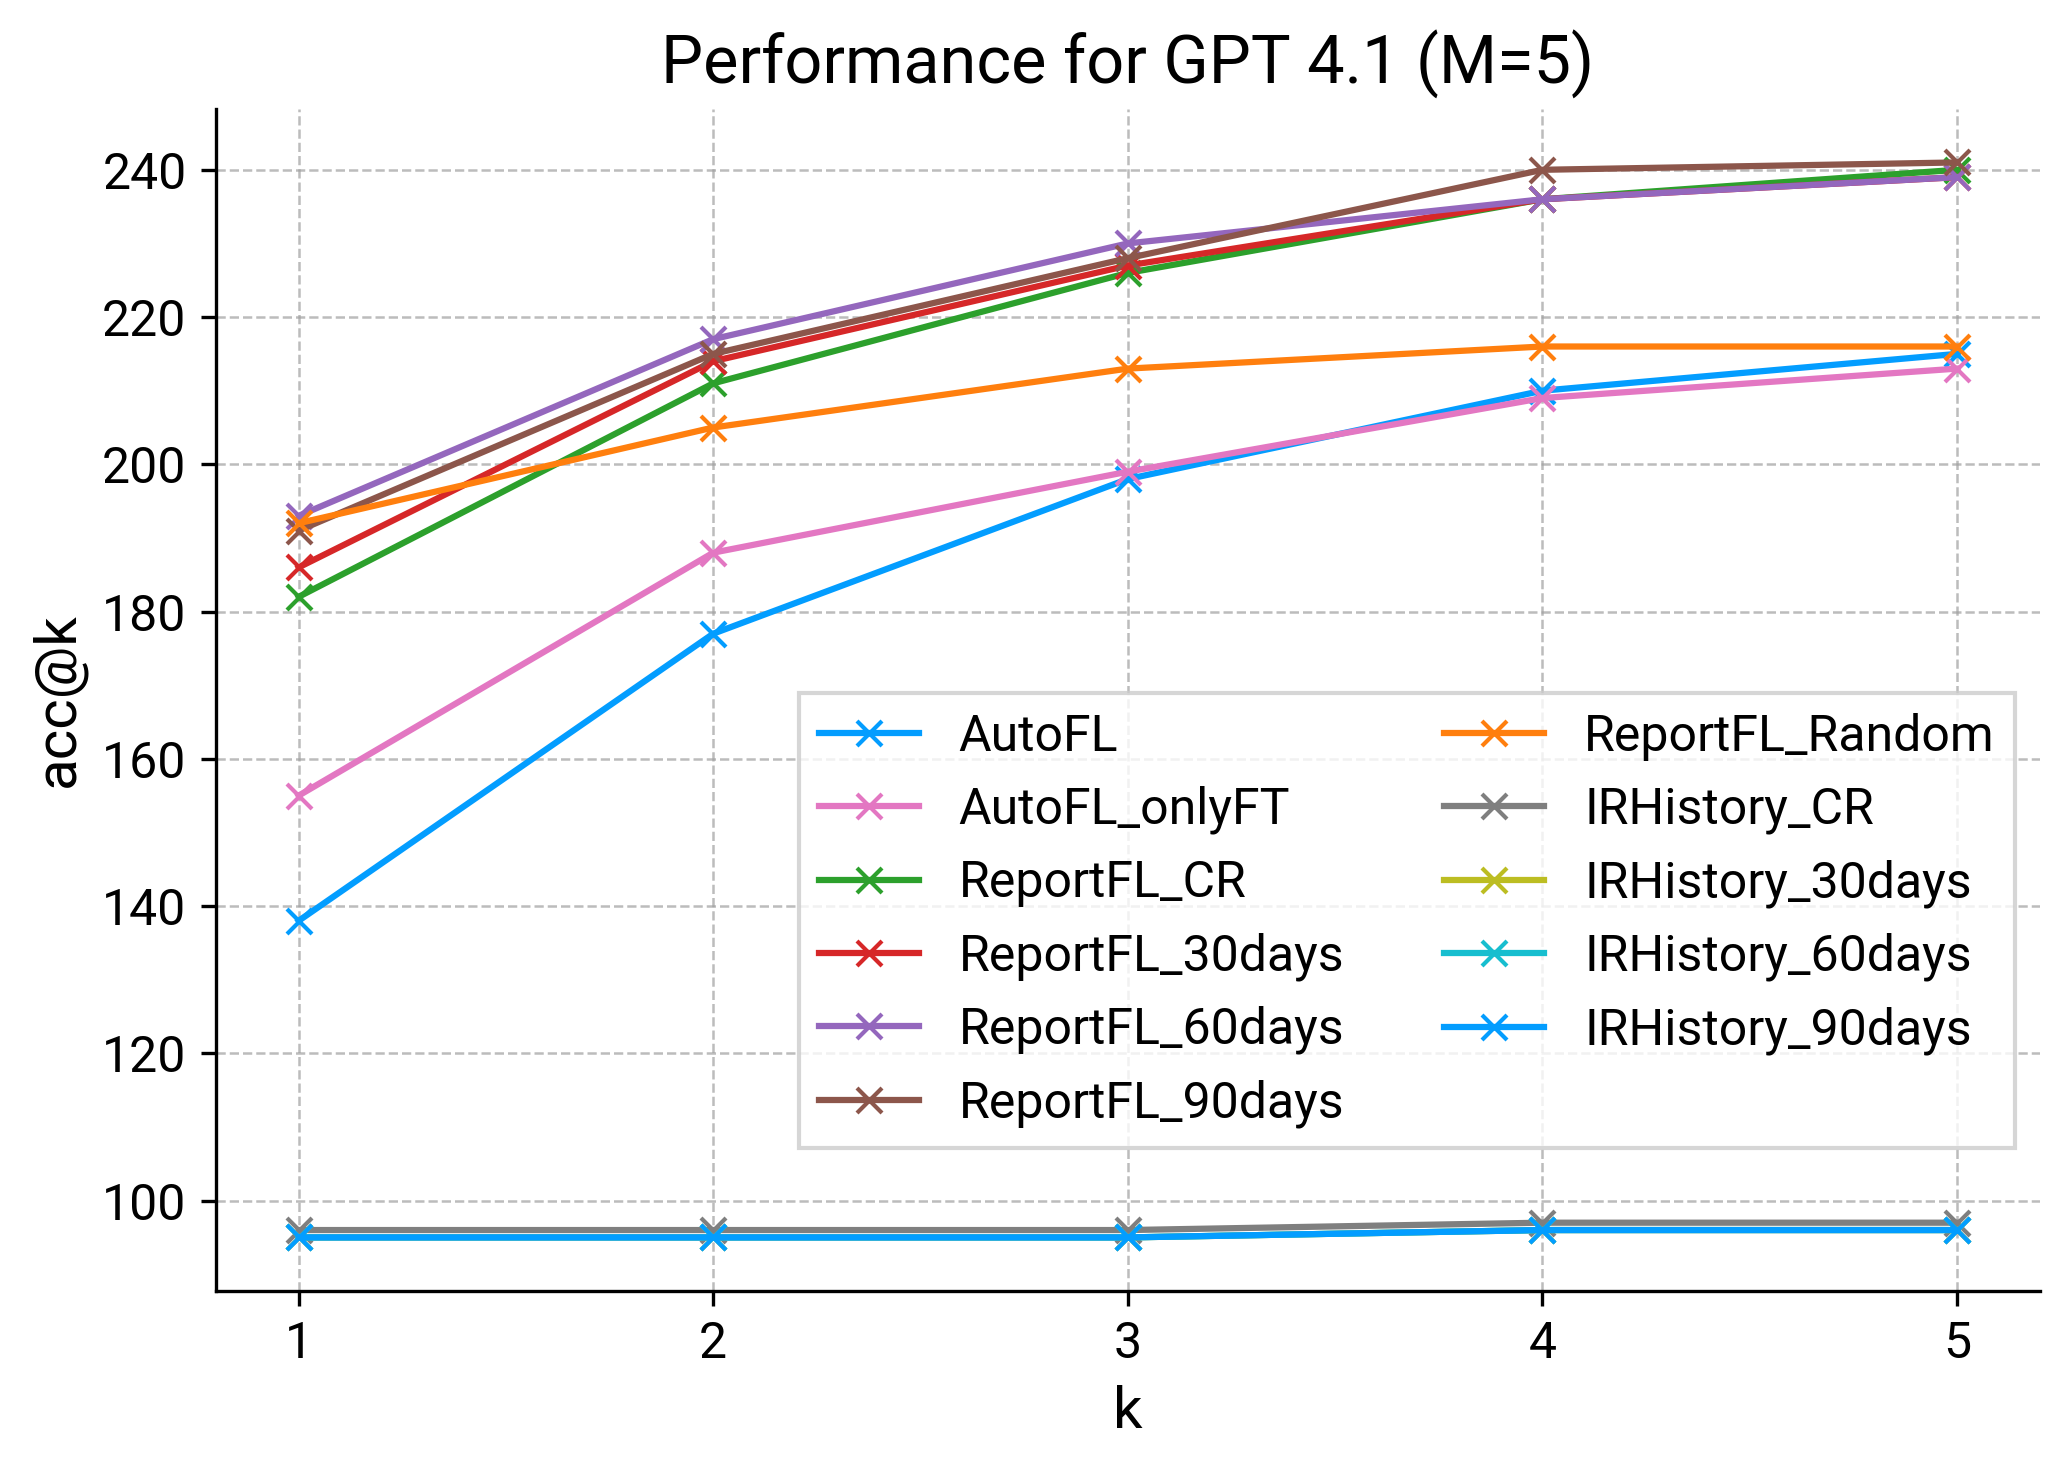

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,138,177,198,210,215,0.596,0.580
1,AutoFL,CLI,10,13,17,18,20,0.461,0.452
2,AutoFL,CODEC,7,9,12,14,14,0.603,0.597
3,AutoFL,COLLECTIONS,1,1,1,1,1,1.000,1.000
4,AutoFL,COMPRESS,22,26,29,33,33,0.593,0.585
...,...,...,...,...,...,...,...,...,...
94,IRHistory_90days,COMPRESS,17,17,17,17,17,0.381,0.335
95,IRHistory_90days,CSV,5,5,5,6,6,0.383,0.342
96,IRHistory_90days,JXPATH,2,2,2,2,2,0.092,0.048
97,IRHistory_90days,LANG,35,35,35,35,35,0.594,0.495



& \multirow{9}{*}{\autofl} & Cli & 9 & 14 & 15 & 19 & 19 & 0.440 & 0.433 & 10 & 13 & 17 & 18 & 20 & 0.461 & 0.452 \\
&  & Codec & 6 & 11 & 12 & 13 & 13 & 0.587 & 0.555 & 7 & 9 & 12 & 14 & 14 & 0.603 & 0.597 \\
&  & Collections & 1 & 1 & 1 & 1 & 1 & \textbf{1.000} & \textbf{1.000} & \textbf{1} & 1 & 1 & 1 & 1 & \textbf{1.000} & \textbf{1.000} \\
&  & Compress & 19 & 23 & 24 & 27 & 28 & 0.515 & 0.502 & 22 & 26 & 29 & 33 & 33 & 0.593 & 0.585 \\
&  & Csv & 7 & 9 & 9 & 9 & 9 & 0.586 & 0.540 & 6 & 9 & 9 & 9 & 9 & 0.550 & 0.504 \\
&  & JXPath & 1 & 1 & 1 & 1 & 2 & 0.064 & 0.065 & 2 & 3 & 4 & 5 & 5 & 0.155 & 0.111 \\
&  & Lang & 34 & 44 & 49 & 51 & 52 & 0.711 & 0.678 & 35 & 46 & 50 & 50 & 52 & 0.727 & 0.717 \\
&  & Math & 53 & 67 & 72 & 74 & 75 & 0.626 & 0.589 & 55 & 70 & 76 & 80 & 81 & 0.658 & 0.640 \\
\cmidrule(lr){3-17}
&  & Overall & 130 & 170 & 183 & 195 & 199 & 0.561 & 0.535 & 138 & 177 & 198 & 210 & 215 & 0.596 & 0.580 \\
\cmidrule(lr){3-17}
\cmidrule(lr){2-17}
& \multirow{9}{*}{\autof

In [38]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_CR",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_90days",
    },
    {
        "name": "reportfl_random",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_Random",
    },
    {
        "name": "irfl_current",
        "gpt_version": "",
        "label": "IRHistory_CR",
    },
    {
        "name": "irfl",
        "gpt_version": "",
        "label": "IRHistory_30days",
    },
    {
        "name": "irfl_60days",
        "gpt_version": "",
        "label": "IRHistory_60days",
    },
    {
        "name": "irfl_90days",
        "gpt_version": "",
        "label": "IRHistory_90days",
    }
]

res_1 = main(exp_list=EXP_LIST, repetition=1, fig_title="Performance for GPT 4.1 (M=1)", legend_loc="center right", legend_ncol=2)
res_2 = main(exp_list=EXP_LIST, repetition=5, fig_title="Performance for GPT 4.1 (M=5)", legend_loc="center right", legend_ncol=2)
print_latex_table(res_1, res_2)

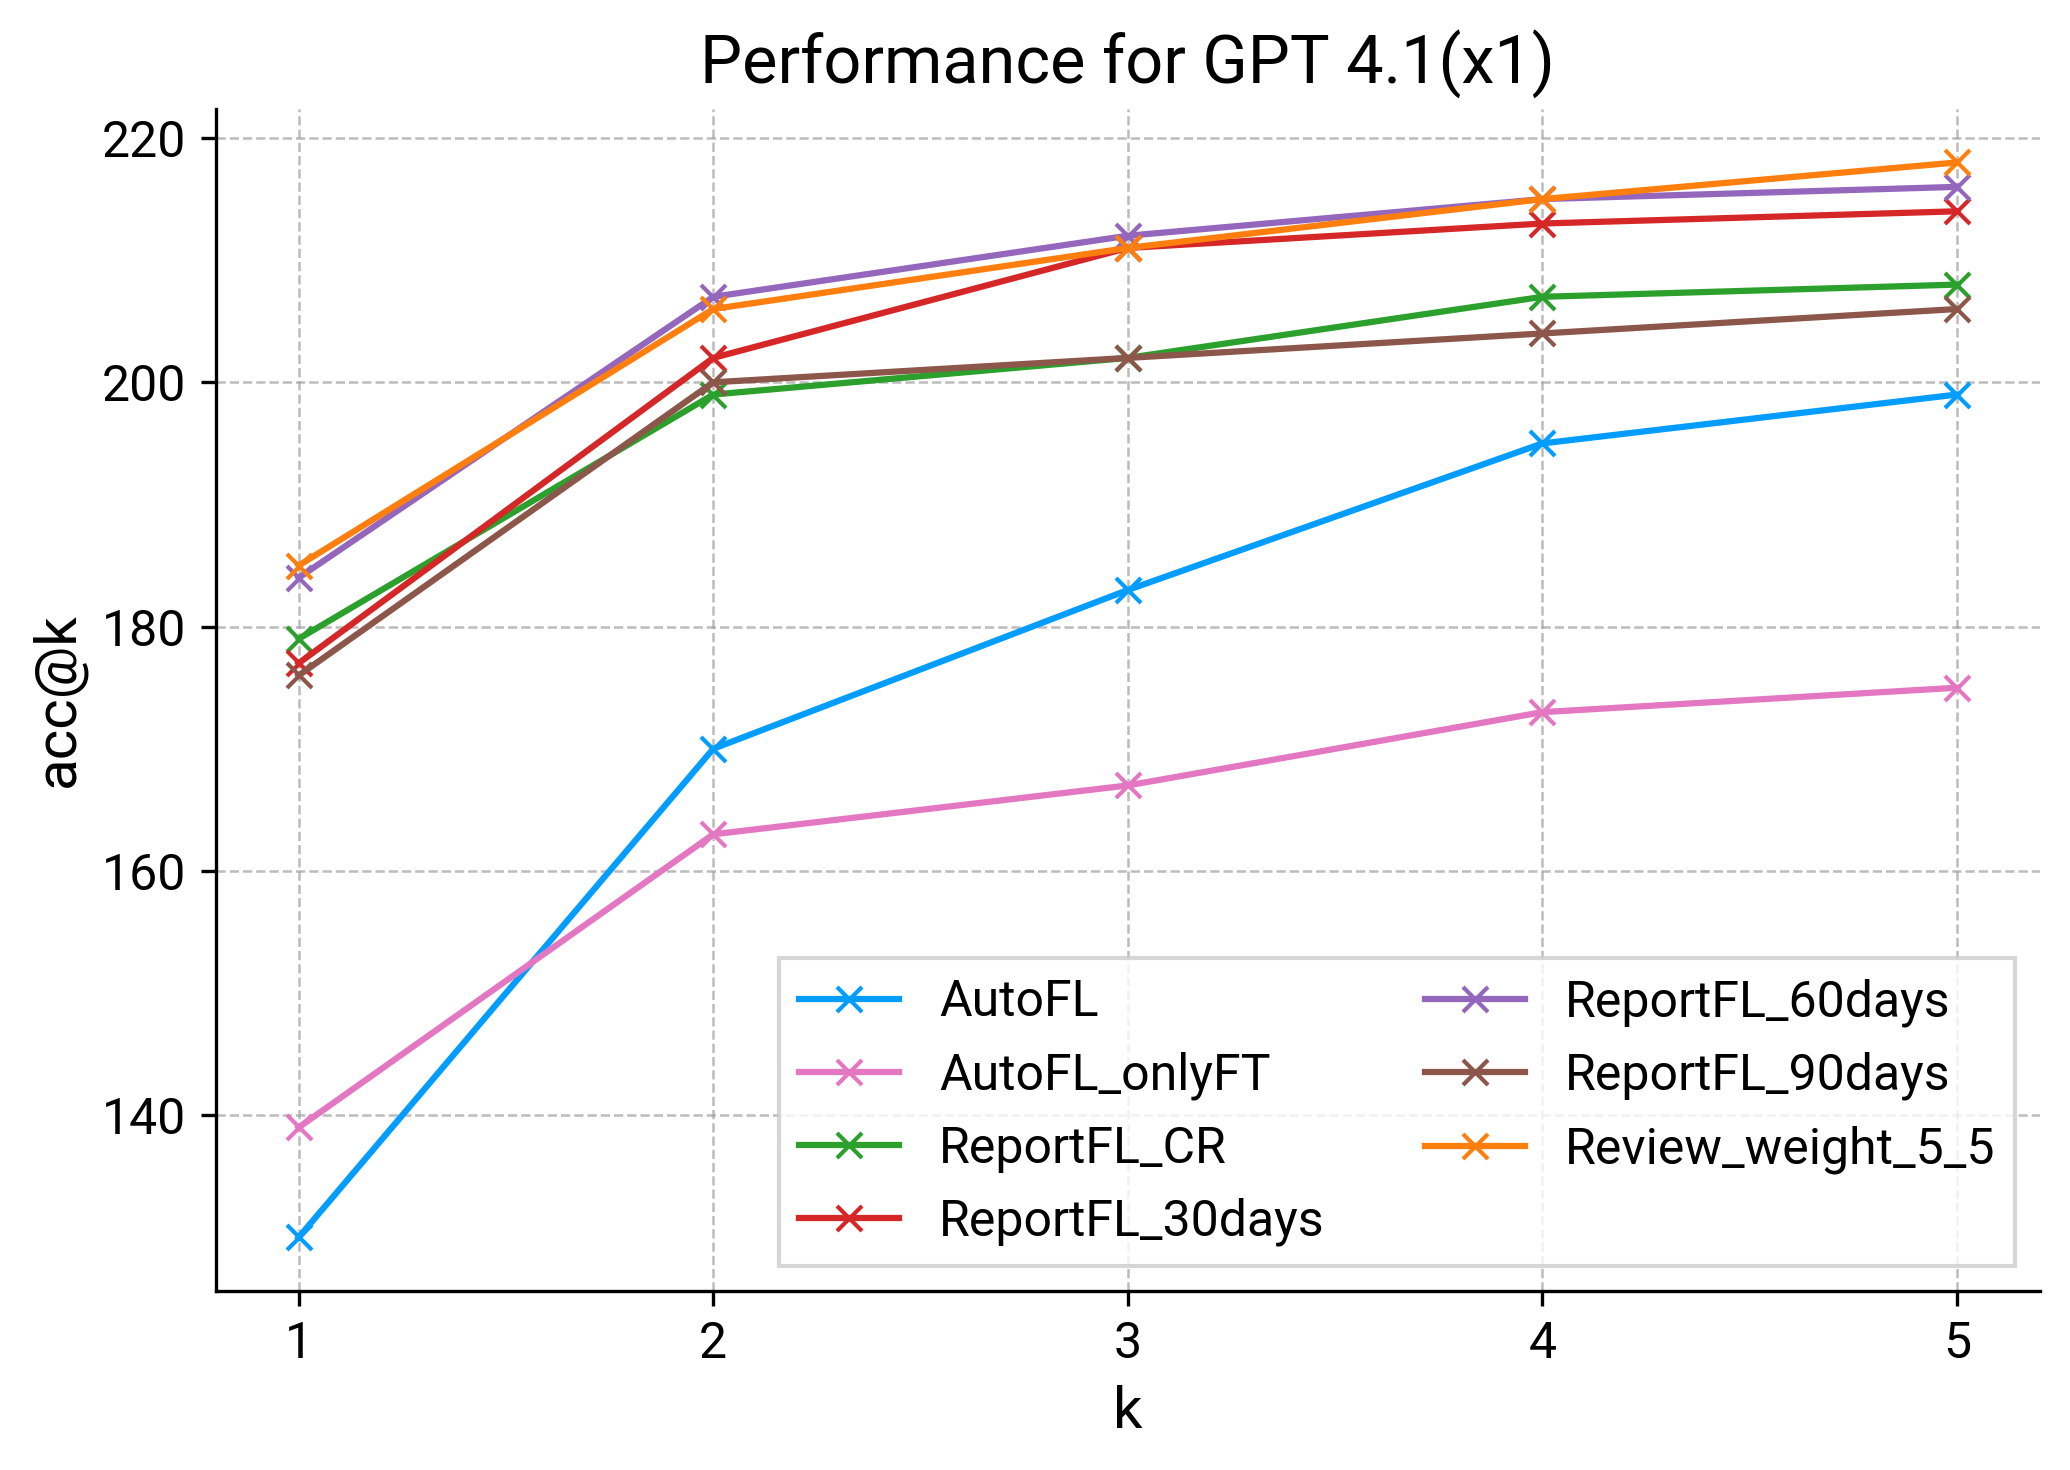

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,130,170,183,195,199,0.561,0.535
1,AutoFL,CLI,9,14,15,19,19,0.440,0.433
2,AutoFL,CODEC,6,11,12,13,13,0.587,0.555
3,AutoFL,COLLECTIONS,1,1,1,1,1,1.000,1.000
4,AutoFL,COMPRESS,19,23,24,27,28,0.515,0.502
...,...,...,...,...,...,...,...,...,...
58,Review_weight_5_5,COMPRESS,26,29,30,30,31,0.626,0.566
59,Review_weight_5_5,CSV,9,11,11,12,12,0.743,0.708
60,Review_weight_5_5,JXPATH,4,5,5,5,5,0.213,0.167
61,Review_weight_5_5,LANG,47,53,54,55,56,0.861,0.743


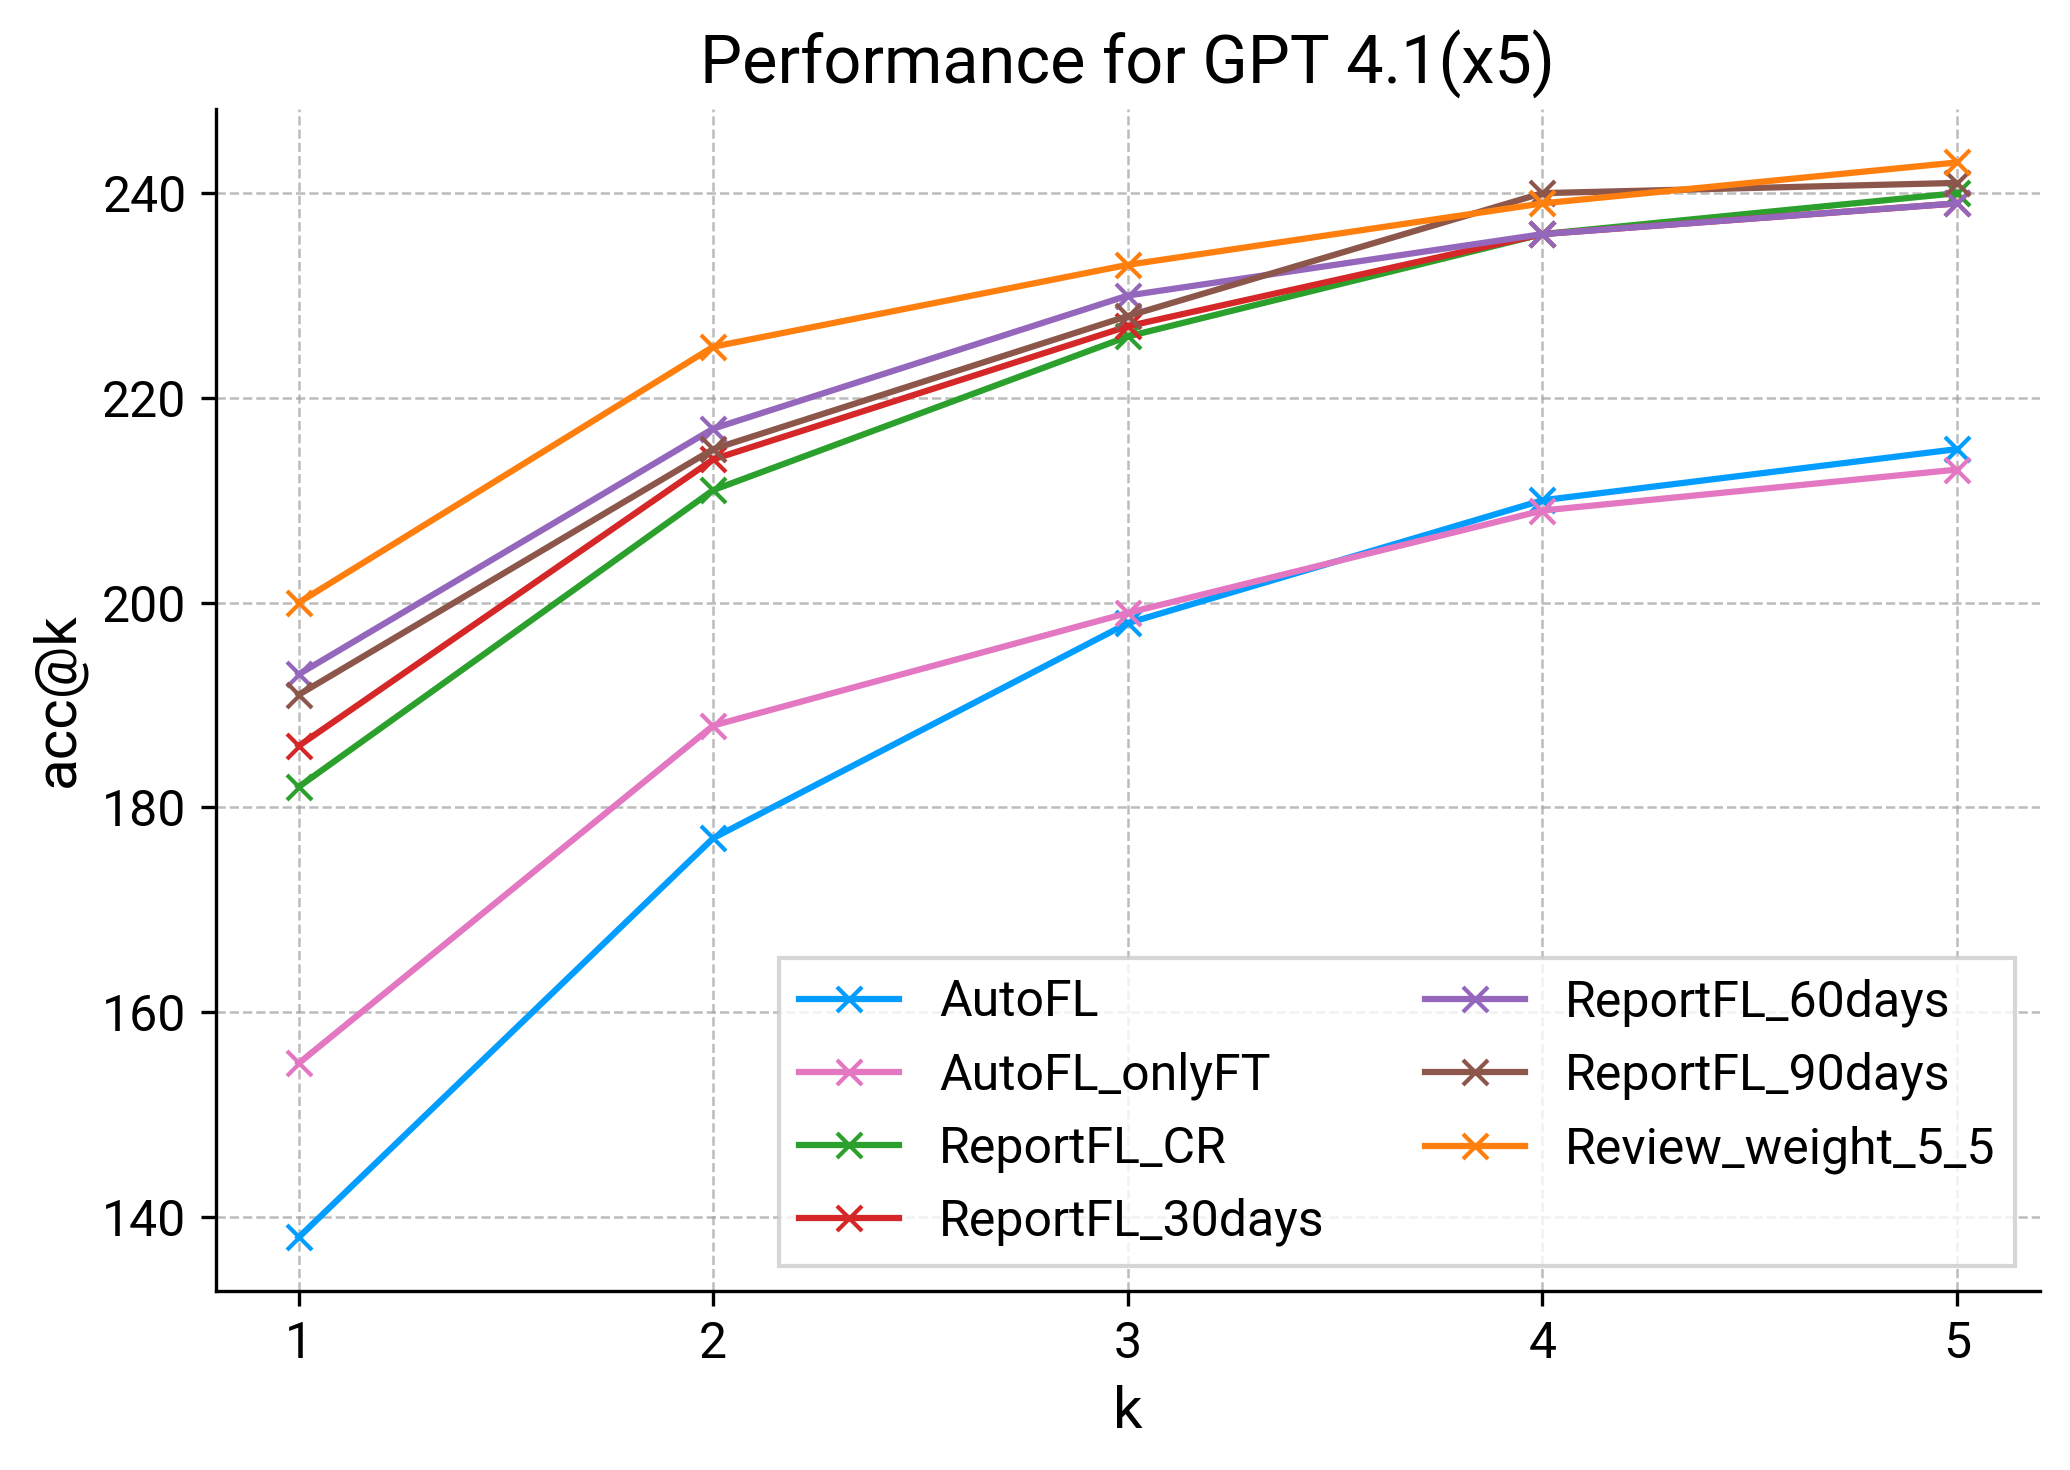

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,138,177,198,210,215,0.596,0.580
1,AutoFL,CLI,10,13,17,18,20,0.461,0.452
2,AutoFL,CODEC,7,9,12,14,14,0.603,0.597
3,AutoFL,COLLECTIONS,1,1,1,1,1,1.000,1.000
4,AutoFL,COMPRESS,22,26,29,33,33,0.593,0.585
...,...,...,...,...,...,...,...,...,...
58,Review_weight_5_5,COMPRESS,26,30,33,35,35,0.658,0.594
59,Review_weight_5_5,CSV,10,12,13,13,14,0.824,0.777
60,Review_weight_5_5,JXPATH,7,8,8,8,8,0.347,0.250
61,Review_weight_5_5,LANG,52,56,57,57,57,0.921,0.837



& \multirow{9}{*}{\autofl} & Cli & 9 & 14 & 15 & 19 & 19 & 0.440 & 0.433 & 10 & 13 & 17 & 18 & 20 & 0.461 & 0.452 \\
&  & Codec & 6 & 11 & 12 & 13 & 13 & 0.587 & 0.555 & 7 & 9 & 12 & 14 & 14 & 0.603 & 0.597 \\
&  & Collections & 1 & 1 & 1 & 1 & 1 & \textbf{1.000} & \textbf{1.000} & \textbf{1} & 1 & 1 & 1 & 1 & \textbf{1.000} & \textbf{1.000} \\
&  & Compress & 19 & 23 & 24 & 27 & 28 & 0.515 & 0.502 & 22 & 26 & 29 & 33 & 33 & 0.593 & 0.585 \\
&  & Csv & 7 & 9 & 9 & 9 & 9 & 0.586 & 0.540 & 6 & 9 & 9 & 9 & 9 & 0.550 & 0.504 \\
&  & JXPath & 1 & 1 & 1 & 1 & 2 & 0.064 & 0.065 & 2 & 3 & 4 & 5 & 5 & 0.155 & 0.111 \\
&  & Lang & 34 & 44 & 49 & 51 & 52 & 0.711 & 0.678 & 35 & 46 & 50 & 50 & 52 & 0.727 & 0.717 \\
&  & Math & 53 & 67 & 72 & 74 & 75 & 0.626 & 0.589 & 55 & 70 & 76 & 80 & 81 & 0.658 & 0.640 \\
\cmidrule(lr){3-17}
&  & Overall & 130 & 170 & 183 & 195 & 199 & 0.561 & 0.535 & 138 & 177 & 198 & 210 & 215 & 0.596 & 0.580 \\
\cmidrule(lr){3-17}
\cmidrule(lr){2-17}
& \multirow{9}{*}{\autof

In [39]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_CR",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_90days",
    },
    {
        "name": "review_weight_5_5",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "Review_weight_5_5",
    }
]

res_1 = main(exp_list=EXP_LIST, repetition=1, fig_title="Performance for GPT 4.1(x1)", legend_loc="lower right", legend_ncol=2)
res_2 = main(exp_list=EXP_LIST, repetition=5, fig_title="Performance for GPT 4.1(x5)", legend_loc="lower right", legend_ncol=2)

print_latex_table(res_1, res_2)

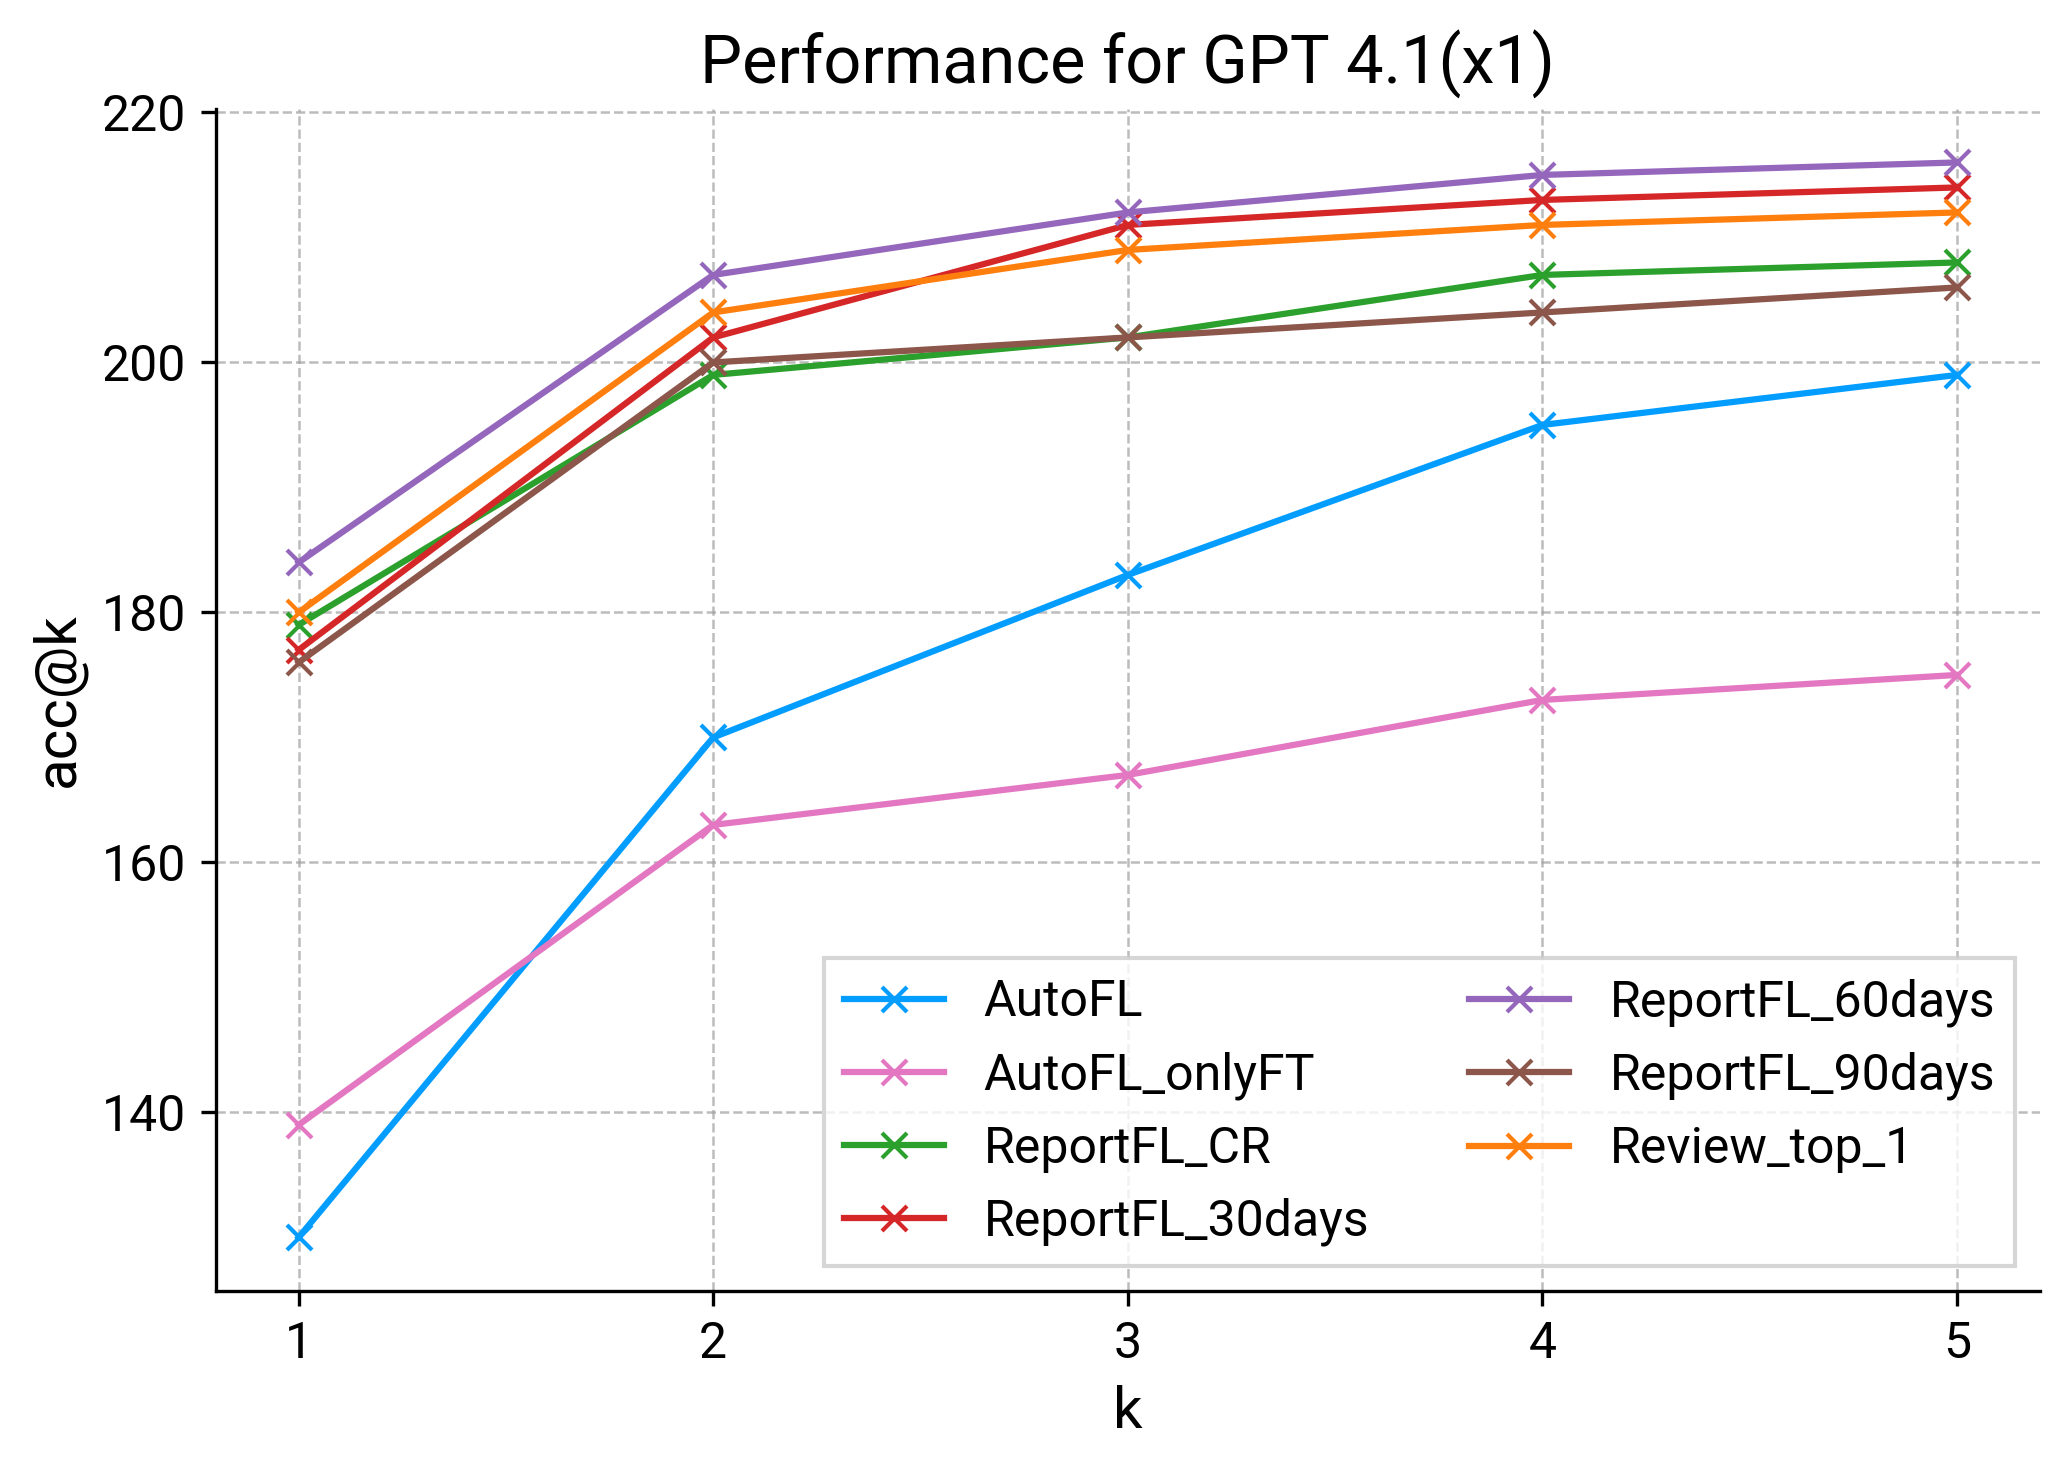

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,130,170,183,195,199,0.561,0.535
1,AutoFL,CLI,9,14,15,19,19,0.440,0.433
2,AutoFL,CODEC,6,11,12,13,13,0.587,0.555
3,AutoFL,COLLECTIONS,1,1,1,1,1,1.000,1.000
4,AutoFL,COMPRESS,19,23,24,27,28,0.515,0.502
...,...,...,...,...,...,...,...,...,...
58,Review_top_1,COMPRESS,26,29,30,31,31,0.630,0.584
59,Review_top_1,CSV,9,13,13,13,13,0.789,0.725
60,Review_top_1,JXPATH,3,3,4,4,4,0.158,0.101
61,Review_top_1,LANG,49,53,53,53,53,0.868,0.754


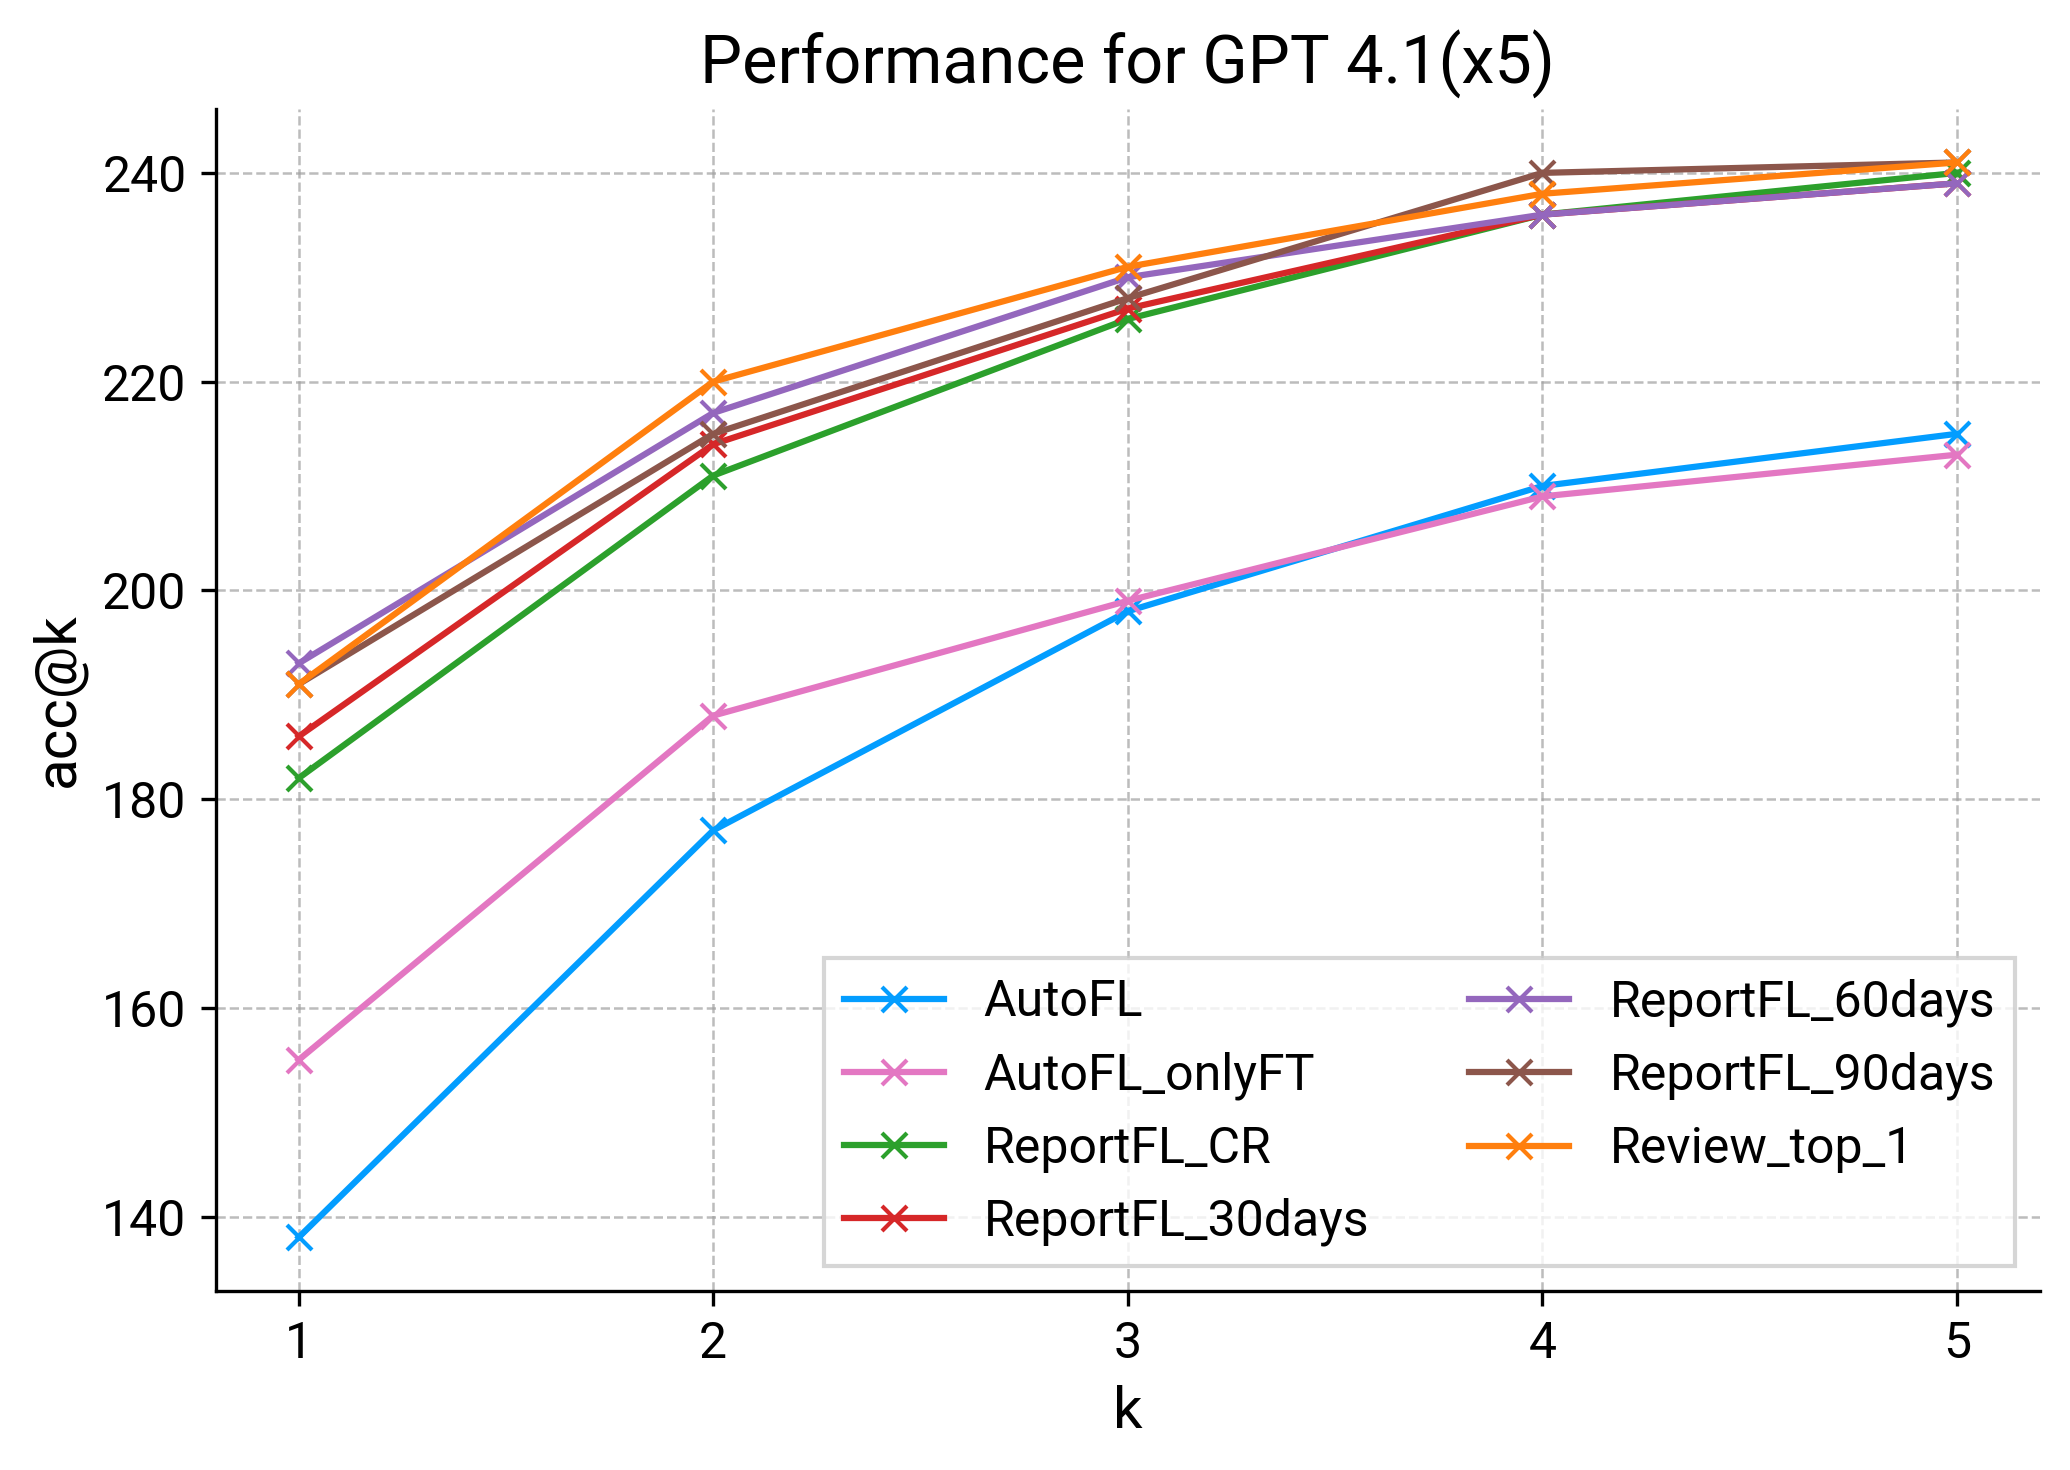

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,138,177,198,210,215,0.596,0.580
1,AutoFL,CLI,10,13,17,18,20,0.461,0.452
2,AutoFL,CODEC,7,9,12,14,14,0.603,0.597
3,AutoFL,COLLECTIONS,1,1,1,1,1,1.000,1.000
4,AutoFL,COMPRESS,22,26,29,33,33,0.593,0.585
...,...,...,...,...,...,...,...,...,...
58,Review_top_1,COMPRESS,24,31,33,33,35,0.638,0.566
59,Review_top_1,CSV,11,12,13,14,14,0.863,0.828
60,Review_top_1,JXPATH,6,8,8,9,9,0.333,0.247
61,Review_top_1,LANG,51,56,57,59,59,0.921,0.846



& \multirow{9}{*}{\autofl} & Cli & 9 & 14 & 15 & 19 & 19 & 0.440 & 0.433 & 10 & 13 & 17 & 18 & 20 & 0.461 & 0.452 \\
&  & Codec & 6 & 11 & 12 & 13 & 13 & 0.587 & 0.555 & 7 & 9 & 12 & 14 & 14 & 0.603 & 0.597 \\
&  & Collections & 1 & 1 & 1 & 1 & 1 & \textbf{1.000} & \textbf{1.000} & \textbf{1} & 1 & 1 & 1 & 1 & \textbf{1.000} & \textbf{1.000} \\
&  & Compress & 19 & 23 & 24 & 27 & 28 & 0.515 & 0.502 & 22 & 26 & 29 & 33 & 33 & 0.593 & 0.585 \\
&  & Csv & 7 & 9 & 9 & 9 & 9 & 0.586 & 0.540 & 6 & 9 & 9 & 9 & 9 & 0.550 & 0.504 \\
&  & JXPath & 1 & 1 & 1 & 1 & 2 & 0.064 & 0.065 & 2 & 3 & 4 & 5 & 5 & 0.155 & 0.111 \\
&  & Lang & 34 & 44 & 49 & 51 & 52 & 0.711 & 0.678 & 35 & 46 & 50 & 50 & 52 & 0.727 & 0.717 \\
&  & Math & 53 & 67 & 72 & 74 & 75 & 0.626 & 0.589 & 55 & 70 & 76 & 80 & 81 & 0.658 & 0.640 \\
\cmidrule(lr){3-17}
&  & Overall & 130 & 170 & 183 & 195 & 199 & 0.561 & 0.535 & 138 & 177 & 198 & 210 & 215 & 0.596 & 0.580 \\
\cmidrule(lr){3-17}
\cmidrule(lr){2-17}
& \multirow{9}{*}{\autof

In [40]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_CR",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_90days",
    },
    {
        "name": "review_top_1",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "Review_top_1",
    }
]

res_1 = main(exp_list=EXP_LIST, repetition=1, fig_title="Performance for GPT 4.1(x1)", legend_loc="lower right", legend_ncol=2)
res_2 = main(exp_list=EXP_LIST, repetition=5, fig_title="Performance for GPT 4.1(x5)", legend_loc="lower right", legend_ncol=2)

print_latex_table(res_1, res_2)

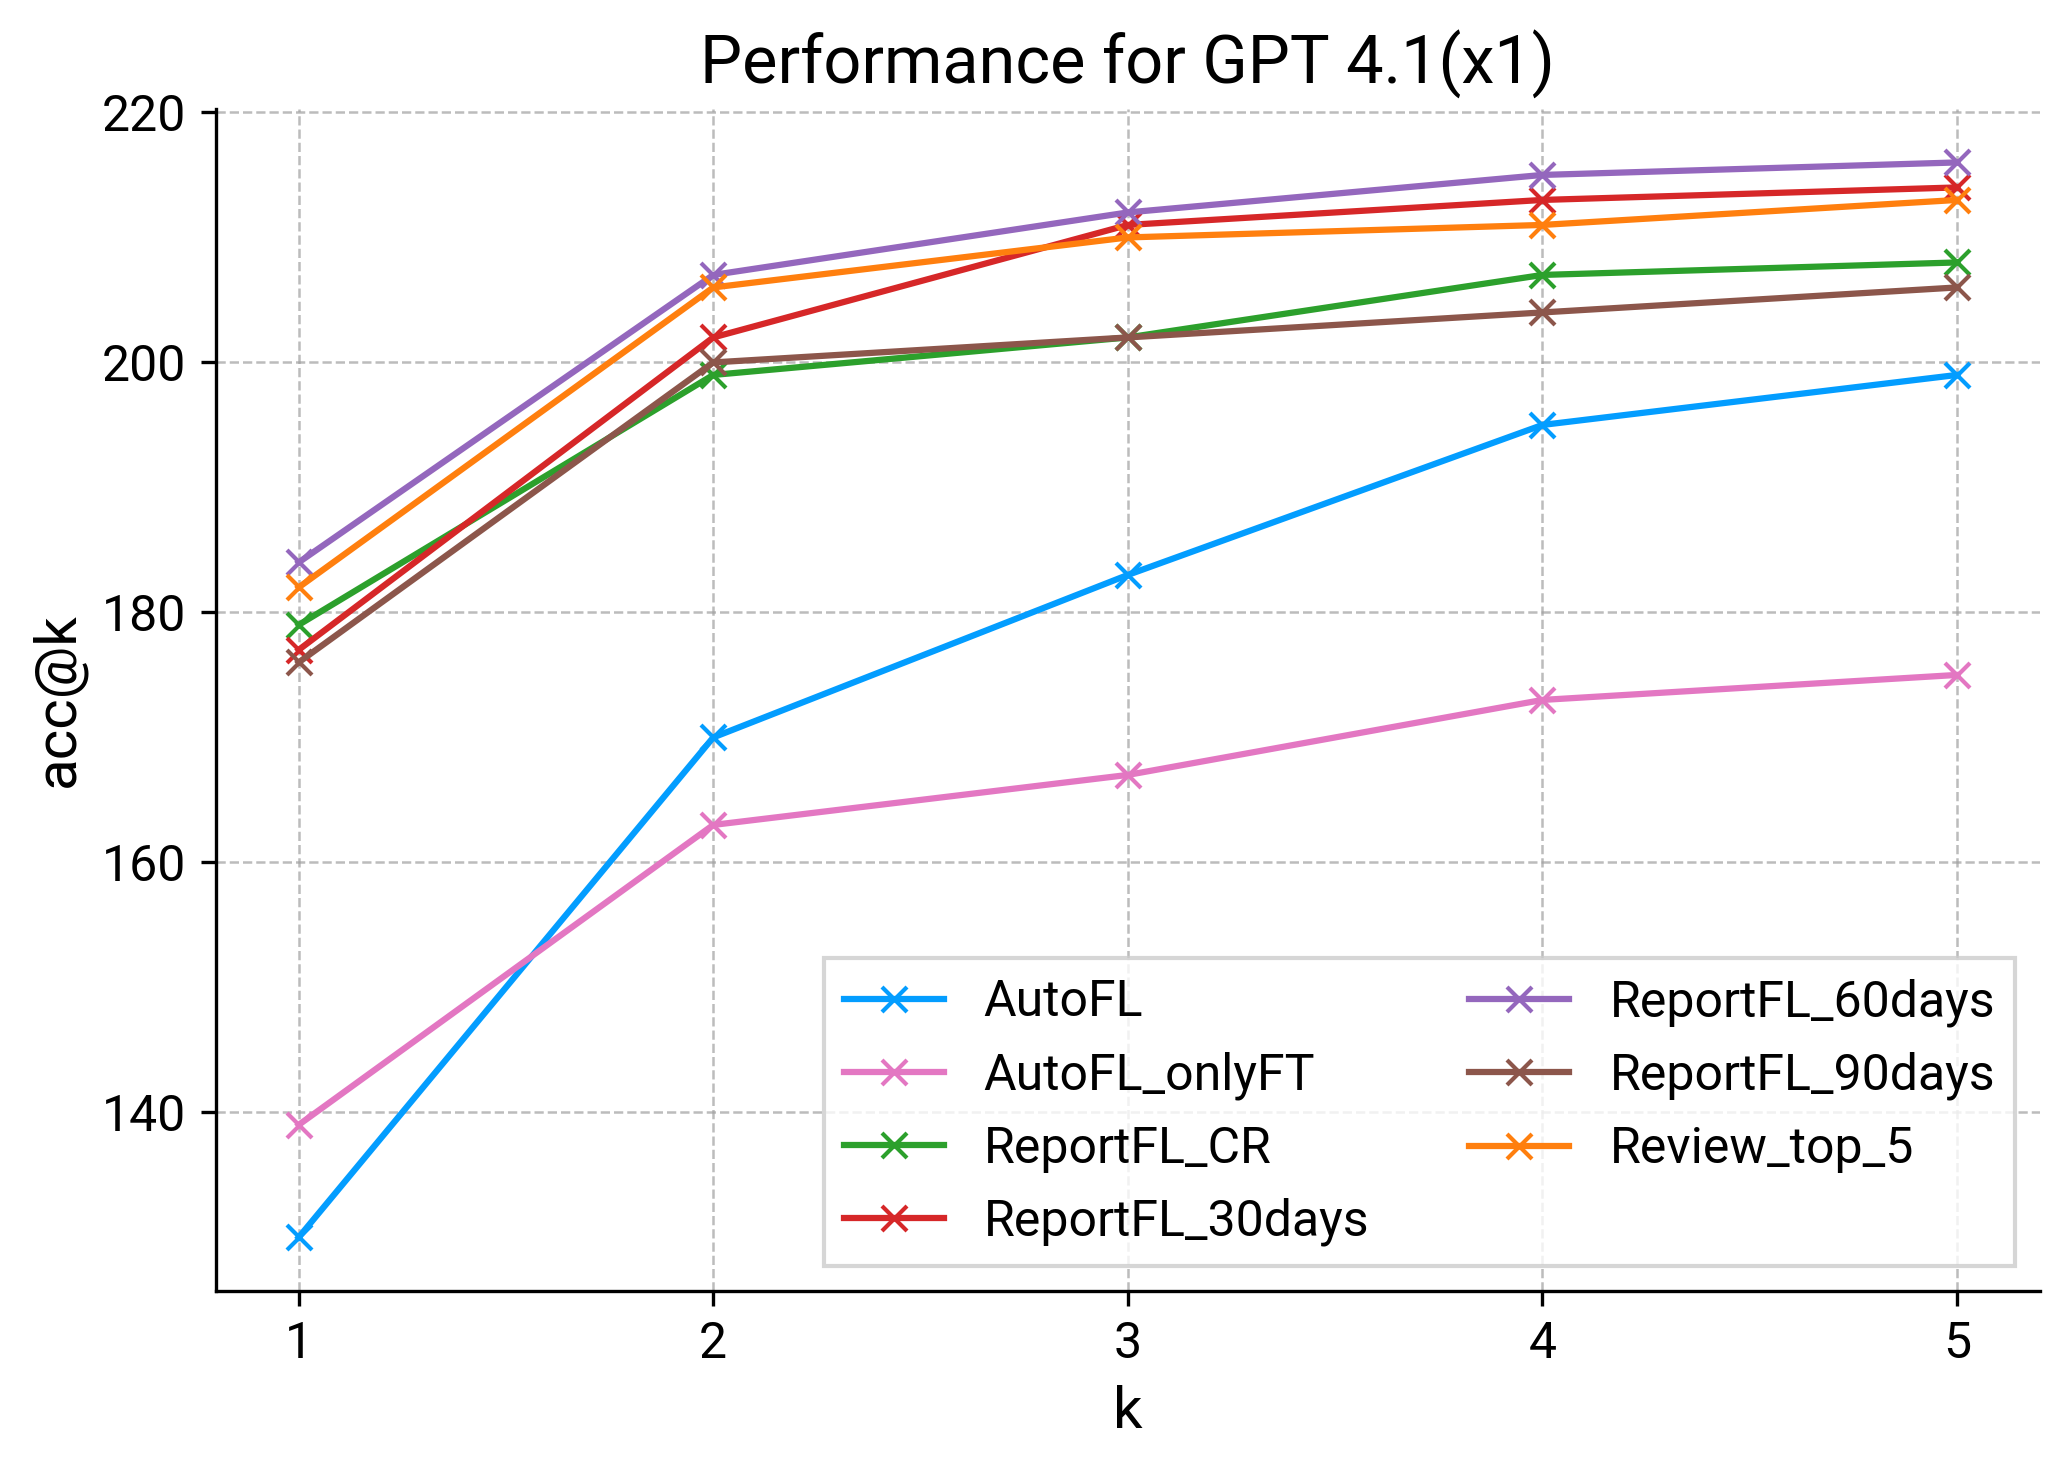

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,130,170,183,195,199,0.561,0.535
1,AutoFL,CLI,9,14,15,19,19,0.440,0.433
2,AutoFL,CODEC,6,11,12,13,13,0.587,0.555
3,AutoFL,COLLECTIONS,1,1,1,1,1,1.000,1.000
4,AutoFL,COMPRESS,19,23,24,27,28,0.515,0.502
...,...,...,...,...,...,...,...,...,...
58,Review_top_5,COMPRESS,26,29,30,30,32,0.632,0.585
59,Review_top_5,CSV,9,12,12,12,12,0.760,0.697
60,Review_top_5,JXPATH,4,4,5,6,6,0.210,0.132
61,Review_top_5,LANG,47,53,53,53,53,0.852,0.740


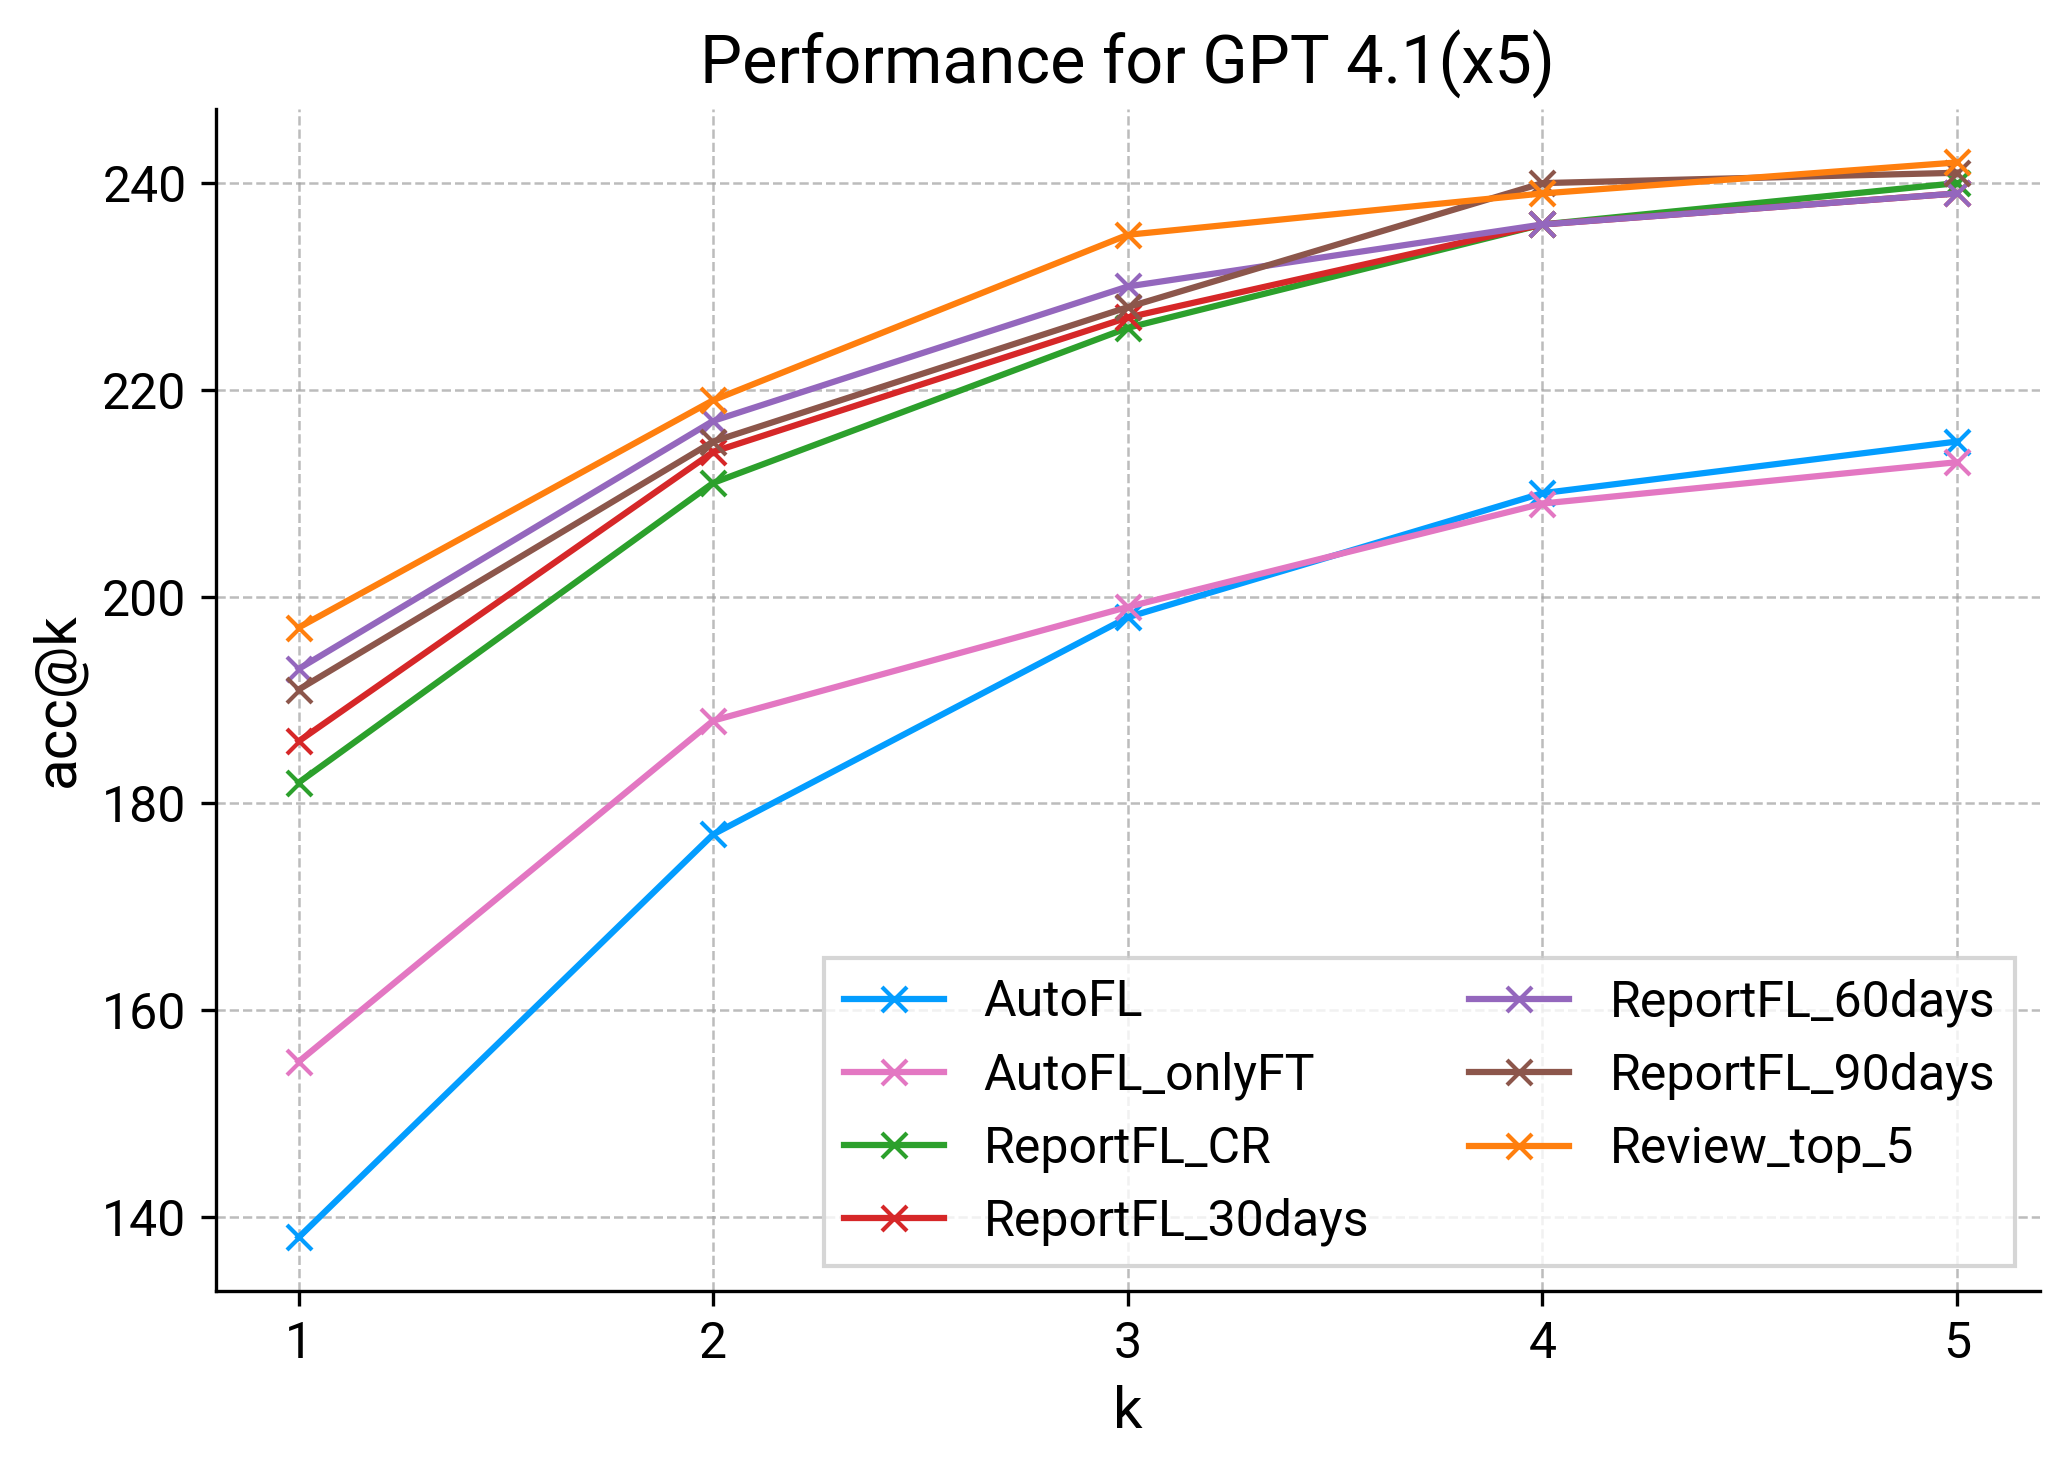

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,138,177,198,210,215,0.596,0.580
1,AutoFL,CLI,10,13,17,18,20,0.461,0.452
2,AutoFL,CODEC,7,9,12,14,14,0.603,0.597
3,AutoFL,COLLECTIONS,1,1,1,1,1,1.000,1.000
4,AutoFL,COMPRESS,22,26,29,33,33,0.593,0.585
...,...,...,...,...,...,...,...,...,...
58,Review_top_5,COMPRESS,24,30,33,34,35,0.635,0.587
59,Review_top_5,CSV,11,12,13,13,14,0.860,0.797
60,Review_top_5,JXPATH,7,7,7,8,8,0.335,0.286
61,Review_top_5,LANG,51,55,58,58,58,0.915,0.845



& \multirow{9}{*}{\autofl} & Cli & 9 & 14 & 15 & 19 & 19 & 0.440 & 0.433 & 10 & 13 & 17 & 18 & 20 & 0.461 & 0.452 \\
&  & Codec & 6 & 11 & 12 & 13 & 13 & 0.587 & 0.555 & 7 & 9 & 12 & 14 & 14 & 0.603 & 0.597 \\
&  & Collections & 1 & 1 & 1 & 1 & 1 & \textbf{1.000} & \textbf{1.000} & \textbf{1} & 1 & 1 & 1 & 1 & \textbf{1.000} & \textbf{1.000} \\
&  & Compress & 19 & 23 & 24 & 27 & 28 & 0.515 & 0.502 & 22 & 26 & 29 & 33 & 33 & 0.593 & 0.585 \\
&  & Csv & 7 & 9 & 9 & 9 & 9 & 0.586 & 0.540 & 6 & 9 & 9 & 9 & 9 & 0.550 & 0.504 \\
&  & JXPath & 1 & 1 & 1 & 1 & 2 & 0.064 & 0.065 & 2 & 3 & 4 & 5 & 5 & 0.155 & 0.111 \\
&  & Lang & 34 & 44 & 49 & 51 & 52 & 0.711 & 0.678 & 35 & 46 & 50 & 50 & 52 & 0.727 & 0.717 \\
&  & Math & 53 & 67 & 72 & 74 & 75 & 0.626 & 0.589 & 55 & 70 & 76 & 80 & 81 & 0.658 & 0.640 \\
\cmidrule(lr){3-17}
&  & Overall & 130 & 170 & 183 & 195 & 199 & 0.561 & 0.535 & 138 & 177 & 198 & 210 & 215 & 0.596 & 0.580 \\
\cmidrule(lr){3-17}
\cmidrule(lr){2-17}
& \multirow{9}{*}{\autof

In [41]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_CR",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "ReportFL_90days",
    },
    {
        "name": "review_top_5",
        "gpt_version": "gpt-4.1-mini-2025-04-14",
        "label": "Review_top_5",
    }
]

res_1 = main(exp_list=EXP_LIST, repetition=1, fig_title="Performance for GPT 4.1(x1)", legend_loc="lower right", legend_ncol=2)
res_2 = main(exp_list=EXP_LIST, repetition=5, fig_title="Performance for GPT 4.1(x5)", legend_loc="lower right", legend_ncol=2)

print_latex_table(res_1, res_2)

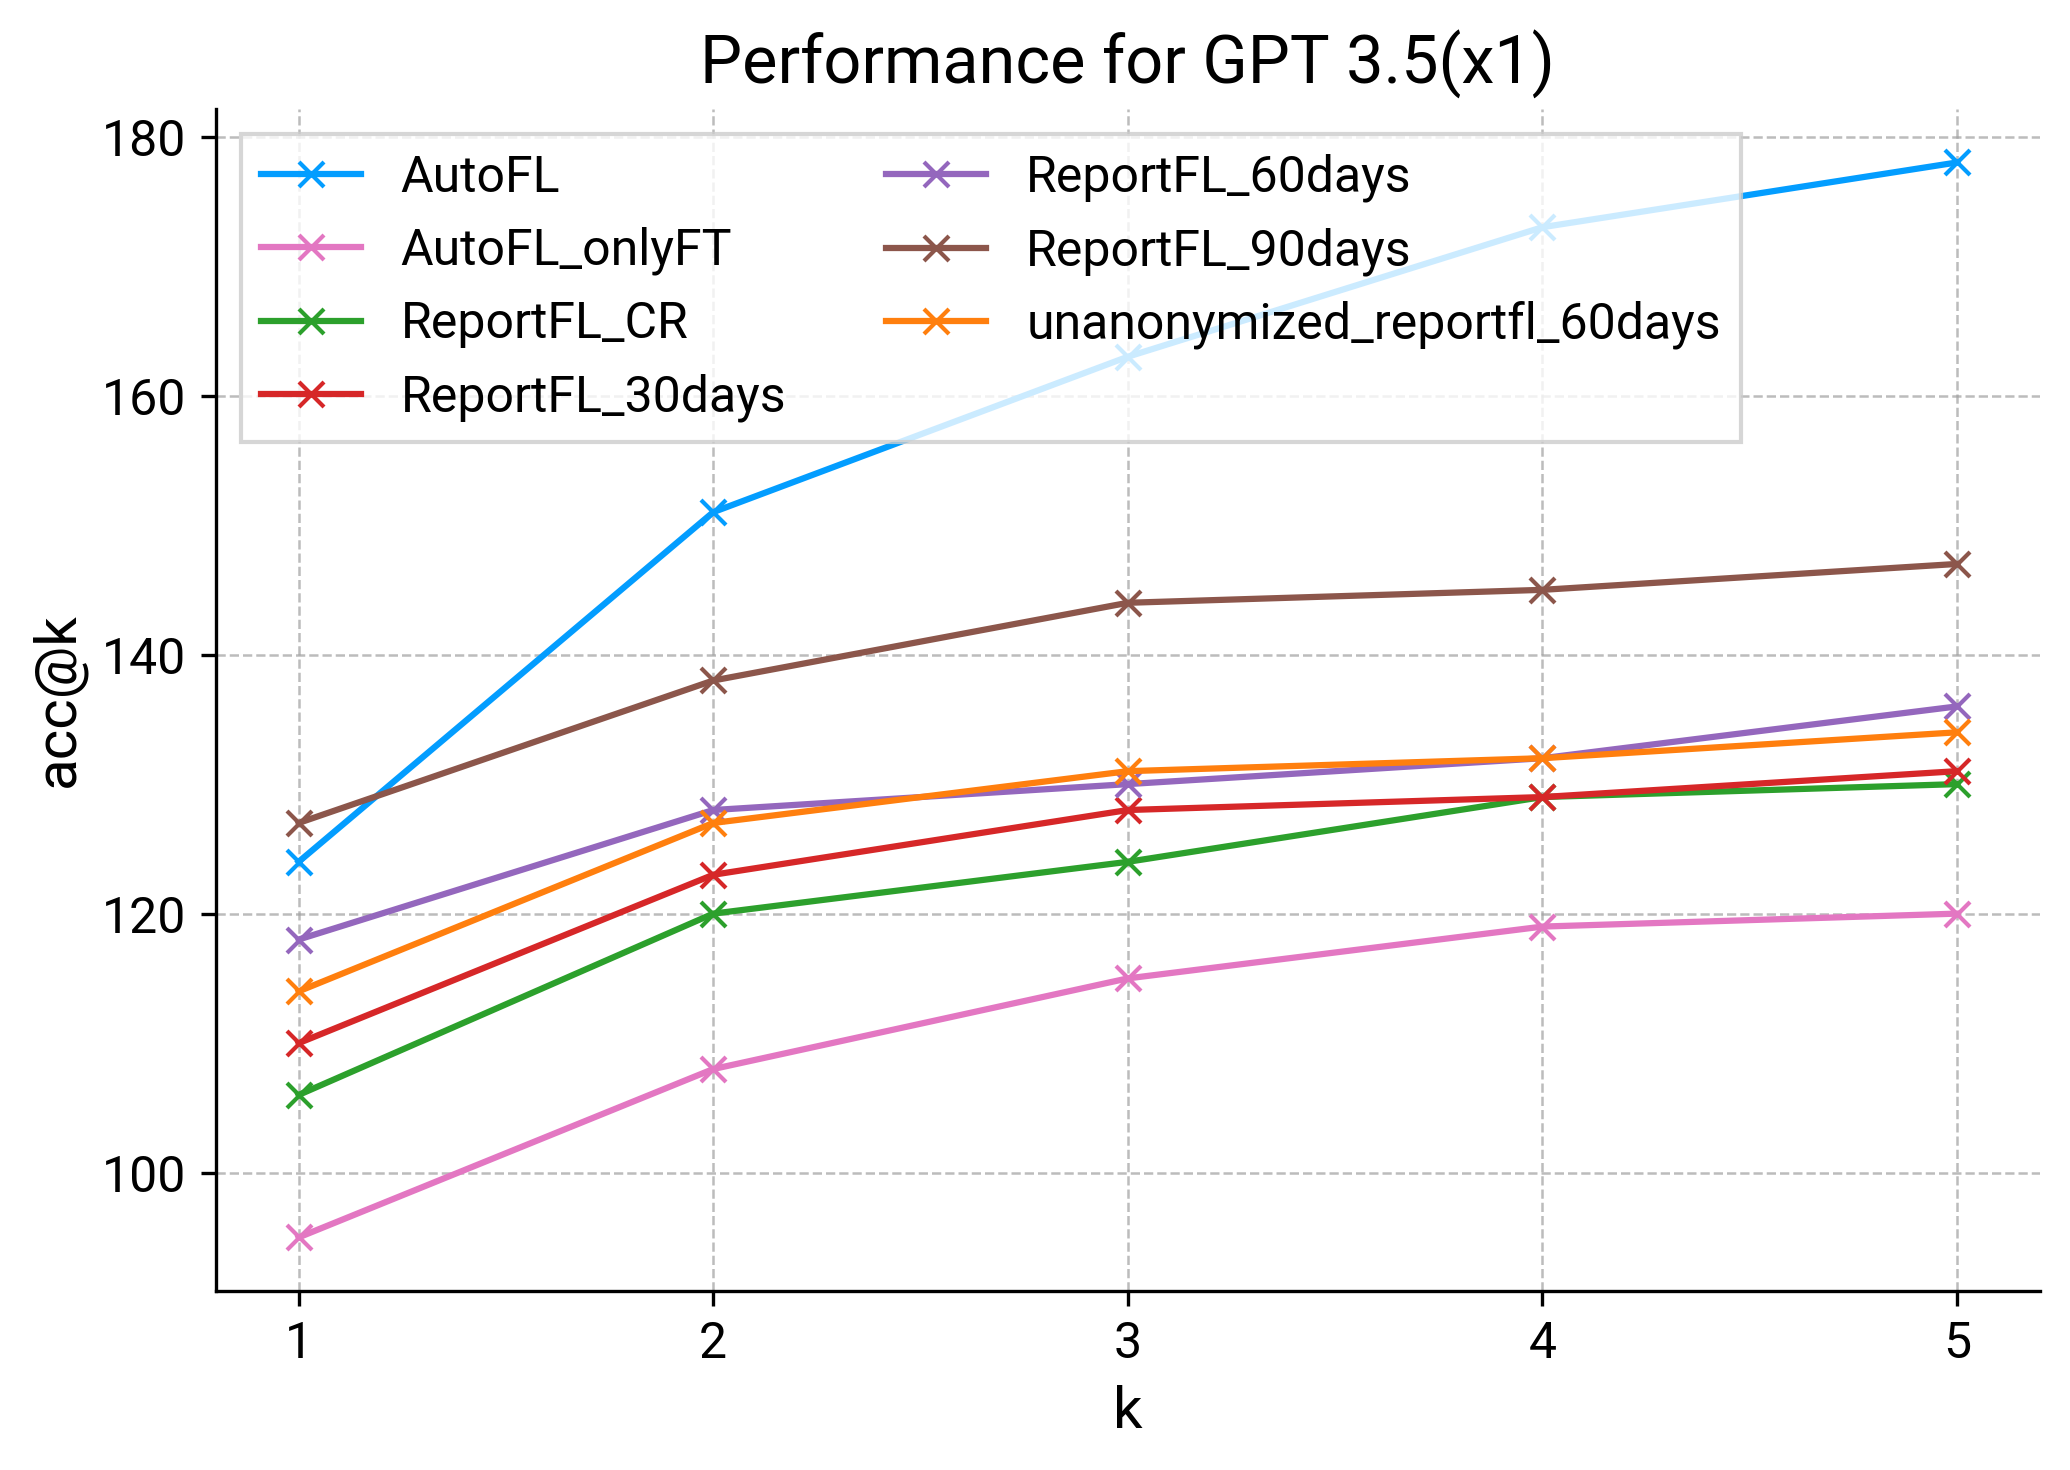

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,124,151,163,173,178,0.521,0.493
1,AutoFL,CLI,10,11,11,12,13,0.388,0.373
2,AutoFL,CODEC,7,8,9,11,11,0.550,0.543
3,AutoFL,COLLECTIONS,0,1,1,1,1,0.500,0.500
4,AutoFL,COMPRESS,17,22,23,25,25,0.477,0.463
...,...,...,...,...,...,...,...,...,...
58,unanonymized_reportfl_60days,COMPRESS,18,19,19,19,19,0.417,0.407
59,unanonymized_reportfl_60days,CSV,5,8,8,9,9,0.496,0.451
60,unanonymized_reportfl_60days,JXPATH,2,2,2,2,2,0.098,0.097
61,unanonymized_reportfl_60days,LANG,31,33,35,35,36,0.568,0.487


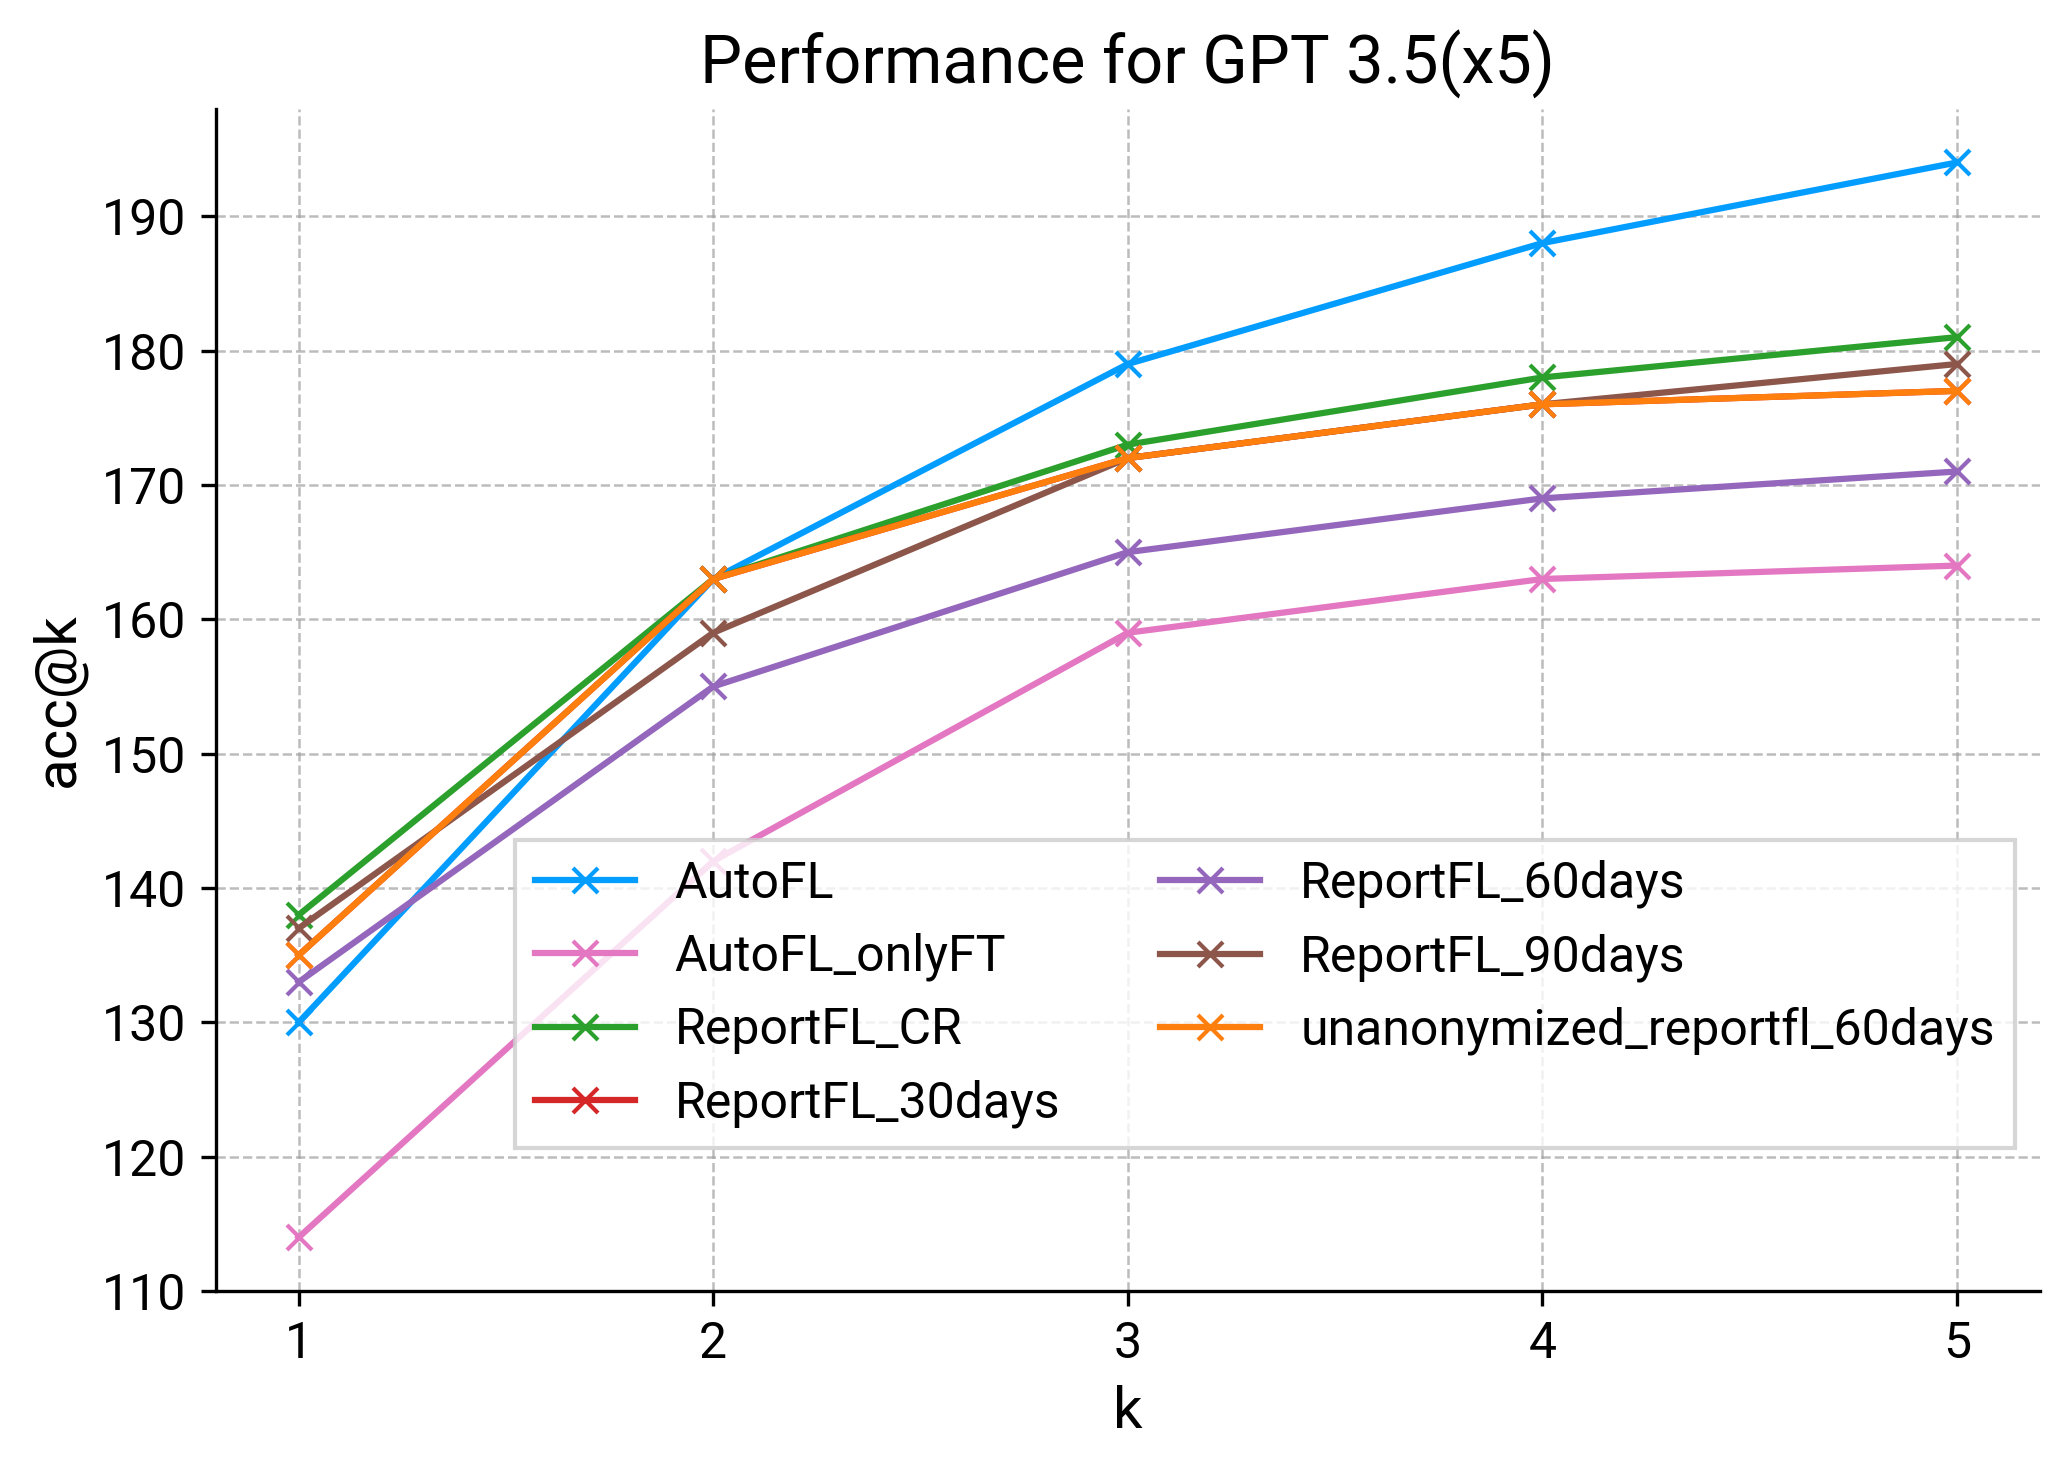

,label,project,Acc@1,Acc@2,Acc@3,Acc@4,Acc@5,Mean Reciprocal Rank (MRR),Mean Average Precision (MAP)
0,AutoFL,ALL,130,163,179,188,194,0.553,0.535
1,AutoFL,CLI,13,14,14,15,15,0.478,0.438
2,AutoFL,CODEC,6,9,9,11,12,0.534,0.526
3,AutoFL,COLLECTIONS,0,0,0,0,1,0.200,0.200
4,AutoFL,COMPRESS,22,26,28,29,30,0.576,0.559
...,...,...,...,...,...,...,...,...,...
58,unanonymized_reportfl_60days,COMPRESS,21,24,27,27,27,0.530,0.493
59,unanonymized_reportfl_60days,CSV,6,8,9,9,9,0.543,0.480
60,unanonymized_reportfl_60days,JXPATH,3,3,3,3,3,0.144,0.121
61,unanonymized_reportfl_60days,LANG,38,44,46,47,48,0.720,0.661



& \multirow{9}{*}{\autofl} & Cli & \textbf{10} & \textbf{11} & \textbf{11} & \textbf{12} & \textbf{13} & \textbf{0.388} & \textbf{0.373} & \textbf{13} & \textbf{14} & 14 & 15 & 15 & \textbf{0.478} & \textbf{0.438} \\
&  & Codec & 7 & 8 & \textbf{9} & \textbf{11} & \textbf{11} & \textbf{0.550} & \textbf{0.543} & 6 & 9 & 9 & 11 & 12 & 0.534 & 0.526 \\
&  & Collections & 0 & 1 & 1 & 1 & 1 & 0.500 & 0.500 & 0 & 0 & 0 & 0 & 1 & 0.200 & 0.200 \\
&  & Compress & 17 & \textbf{22} & \textbf{23} & \textbf{25} & \textbf{25} & \textbf{0.477} & \textbf{0.463} & \textbf{22} & \textbf{26} & \textbf{28} & \textbf{29} & \textbf{30} & \textbf{0.576} & \textbf{0.559} \\
&  & Csv & \textbf{8} & \textbf{8} & \textbf{8} & 8 & 8 & \textbf{0.590} & \textbf{0.544} & \textbf{6} & 7 & 7 & 8 & 8 & 0.500 & \textbf{0.481} \\
&  & JXPath & 0 & 0 & 0 & 0 & 1 & 0.019 & 0.021 & 1 & 1 & 2 & \textbf{3} & \textbf{4} & 0.089 & 0.061 \\
&  & Lang & 36 & \textbf{44} & \textbf{48} & \textbf{49} & \textbf{50} & \textbf{0.723}

In [42]:
EXP_LIST = [
    {
        "name": "autofl",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "AutoFL",
    },
    {
        "name": "autofl_onlyft",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "AutoFL_onlyFT",
    },
    {
        "name": "current",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_CR",
    },
    {
        "name": "reportfl",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_30days",
    },    
    {
        "name": "reportfl_60days",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_60days",
    },
    {
        "name": "reportfl_90days",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "ReportFL_90days",
    },
    {
        "name": "reportfl_unanonymized_combined",
        "gpt_version": "gpt-3.5-turbo-0125",
        "label": "unanonymized_reportfl_60days",
    }
]

res_1 = main(exp_list=EXP_LIST, repetition=1, fig_title="Performance for GPT 3.5(x1)", legend_loc="upper left", legend_ncol=2)
res_2 = main(exp_list=EXP_LIST, repetition=5, fig_title="Performance for GPT 3.5(x5)", legend_loc="center right", legend_ncol=2)
print_latex_table(res_1, res_2)